## Electric Vehicle Market Analysis
**-Divya Maheshkumar**

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import regularizers
from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import xgboost as xgb
from sklearn.tree import DecisionTreeClassifier
from scipy.stats import randint
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.svm import SVC
from sklearn.model_selection import GroupShuffleSplit

In [ ]:
#Read the dataset
df = pd.read_csv("Electric_Vehicle_Population_Data_complete.csv")

#Print 5 rows from dataframe
df.head()

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,5YJ3E1EBXK,King,Seattle,WA,98178.0,2019,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,220.0,37000.0,37.0,477309682,POINT (-122.23825 47.49461),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10
1,5YJYGDEE3L,Kitsap,Poulsbo,WA,98370.0,2020,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,291.0,47000.0,23.0,109705683,POINT (-122.64681 47.73689),PUGET SOUND ENERGY INC,5.303509e+10
2,KM8KRDAF5P,Kitsap,Olalla,WA,98359.0,2023,HYUNDAI,IONIQ 5,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,40000.0,26.0,230390492,POINT (-122.54729 47.42602),PUGET SOUND ENERGY INC,5.303509e+10
3,5UXTA6C0XM,Kitsap,Seabeck,WA,98380.0,2021,BMW,X5,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,30.0,60000.0,35.0,267929112,POINT (-122.81585 47.64509),PUGET SOUND ENERGY INC,5.303509e+10
4,JTMAB3FV7P,Thurston,Rainier,WA,98576.0,2023,TOYOTA,RAV4 PRIME,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,42.0,45000.0,2.0,236505139,POINT (-122.68993 46.88897),PUGET SOUND ENERGY INC,5.306701e+10


In [5]:
#Print shape of dataframe
print(df.shape)

#Print columns in dataframe
df.columns

(235692, 17)


Index(['VIN (1-10)', 'County', 'City', 'State', 'Postal Code', 'Model Year',
       'Make', 'Model', 'Electric Vehicle Type',
       'Clean Alternative Fuel Vehicle (CAFV) Eligibility', 'Electric Range',
       'Base MSRP', 'Legislative District', 'DOL Vehicle ID',
       'Vehicle Location', 'Electric Utility', '2020 Census Tract'],
      dtype='object')

In [6]:
#Describe the numerical values in the dataset to include their count, mean, std deviation, min, max
df.describe()

,Postal Code,Model Year,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,2020 Census Tract
count,235689.000000,235692.000000,235656.000000,235656.000000,235198.000000,2.356920e+05,2.356890e+05
mean,98177.656463,2021.406658,46.262569,47088.455320,28.879519,2.353127e+08,5.298066e+10
std,2524.218661,2.991908,84.045829,16031.561011,14.904644,6.799098e+07,1.521066e+09
min,1731.000000,2000.000000,0.000000,13000.000000,1.000000,4.385000e+03,1.001020e+09
25%,98052.000000,2020.000000,0.000000,37000.000000,17.000000,2.053457e+08,5.303301e+10
50%,98126.000000,2023.000000,0.000000,44000.000000,32.000000,2.522795e+08,5.303303e+10
75%,98374.000000,2024.000000,38.000000,50000.000000,42.000000,2.696401e+08,5.305307e+10
max,99577.000000,2025.000000,337.000000,845000.000000,49.000000,4.792548e+08,5.602100e+10


In [7]:
#Show information about the data types, non null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 235692 entries, 0 to 235691
Data columns (total 17 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   VIN (1-10)                                         235692 non-null  object 
 1   County                                             235689 non-null  object 
 2   City                                               235689 non-null  object 
 3   State                                              235692 non-null  object 
 4   Postal Code                                        235689 non-null  float64
 5   Model Year                                         235692 non-null  int64  
 6   Make                                               235692 non-null  object 
 7   Model                                              235692 non-null  object 
 8   Electric Vehicle Type                              235692 non-null  object

In [ ]:
#Check if there are any duplicate records
df.duplicated().any()

np.False_

## Exploratory Data Analysis

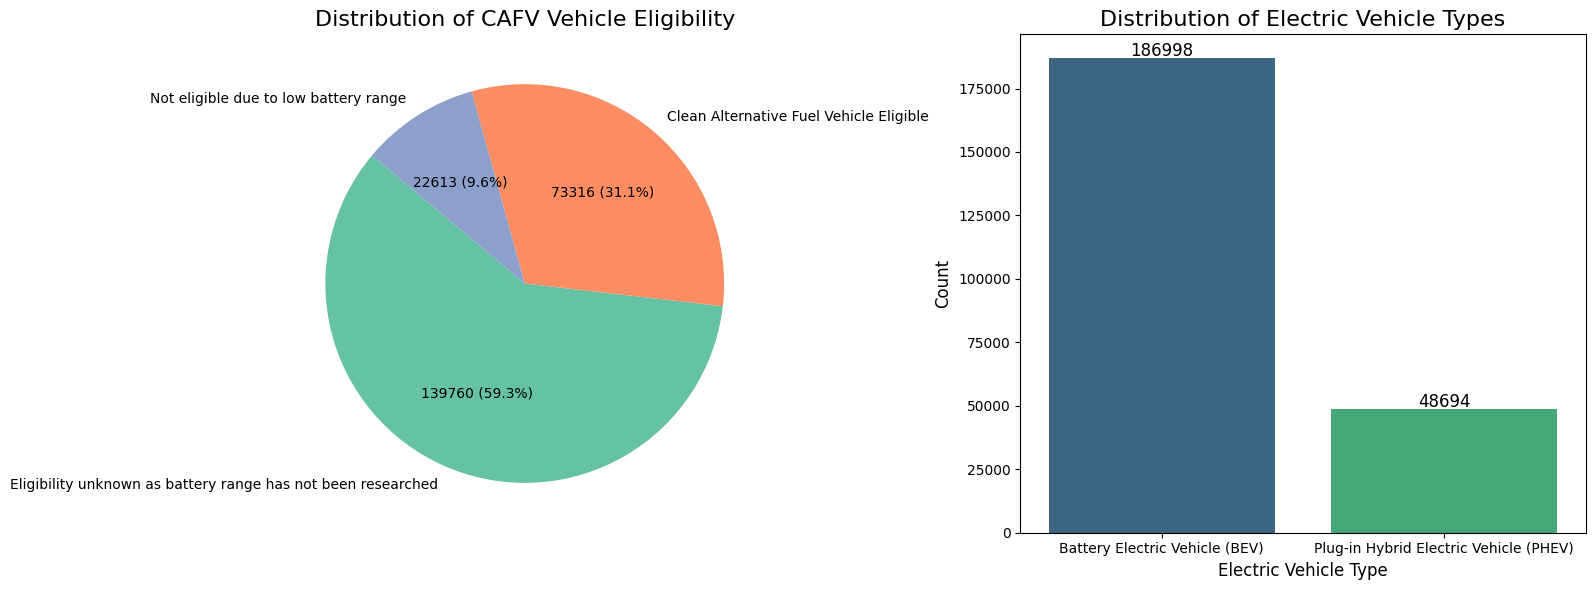

In [ ]:
#Distribution of CAFV Vehicle Eligibility and Distribution of Electric Vehicle Types

# Create a figure with 1 row and 2 columns for side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Pie chart for the distribution of CAFV vehicle counts
CAFV = df['Clean Alternative Fuel Vehicle (CAFV) Eligibility'].value_counts()

# Function to format the actual count and percentage in the pie chart
def func(pct, allvals):
    absolute = int(pct / 100. * sum(allvals))
    return f"{absolute} ({pct:.1f}%)"  # Format to include both count and percentage

# Pie chart with rotation (90 degrees)
axes[0].pie(CAFV.values, labels=CAFV.index, autopct=lambda pct: func(pct, CAFV.values), colors=plt.cm.Set2.colors, startangle=140)
axes[0].set_title('Distribution of CAFV Vehicle Eligibility', fontsize=16)

#Barplot for the distribution of Electric Vehicle Types
ev_type_counts = df['Electric Vehicle Type'].value_counts()
sns.barplot(x=ev_type_counts.index, y=ev_type_counts.values, hue=ev_type_counts.index, palette='viridis', ax=axes[1])

#Title and labels to the bar plot
axes[1].set_title('Distribution of Electric Vehicle Types', fontsize=16)
axes[1].set_xlabel('Electric Vehicle Type', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)

# Annotate actual values on the bar plot
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', fontsize=12, color='black',
                     xytext=(0, 5), textcoords='offset points')

# Display the plot
plt.tight_layout()
plt.show()


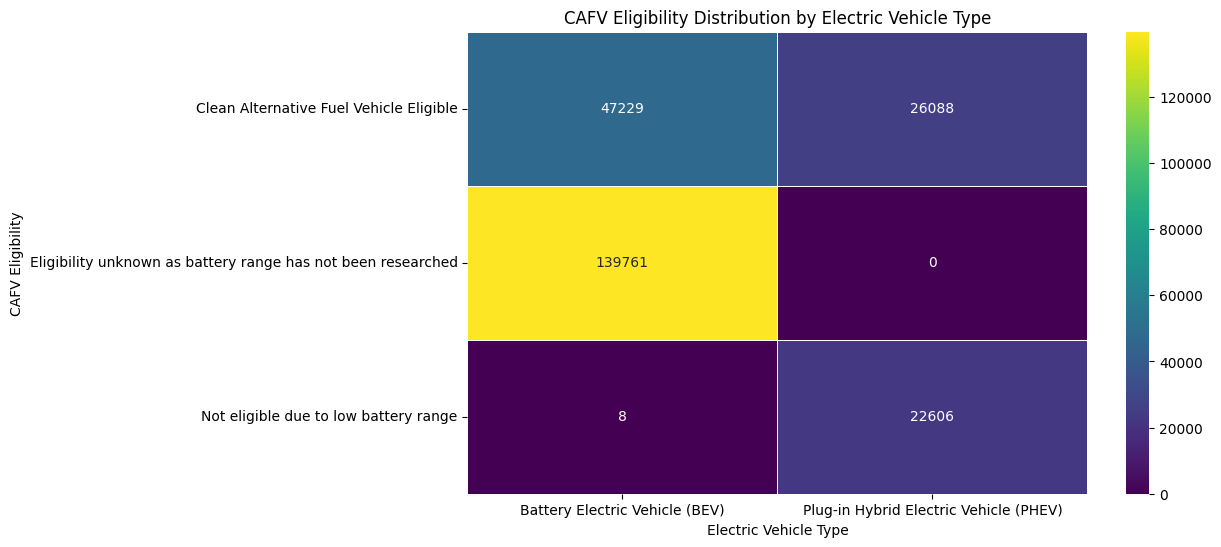

In [ ]:
#CAFV Eligibility Distribution by Electric Vehicle Type

# Pivot table to count CAFV eligibility by Electric Vehicle Type
cafv_heatmap_data = df.pivot_table(index='Clean Alternative Fuel Vehicle (CAFV) Eligibility',
                                   columns='Electric Vehicle Type',
                                   aggfunc='size', fill_value=0)

# Plotting the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(cafv_heatmap_data, annot=True, cmap='viridis', fmt='d', linewidths=0.5)
plt.title('CAFV Eligibility Distribution by Electric Vehicle Type', fontsize=12)
plt.ylabel('CAFV Eligibility')
plt.xlabel('Electric Vehicle Type')
plt.show()


/var/folders/lj/7bdznky91854yv4wc8x1pt8m0000gp/T/ipykernel_75180/1708885021.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(yr_counts, x="Model Year", y="Vehicle count", palette="viridis")


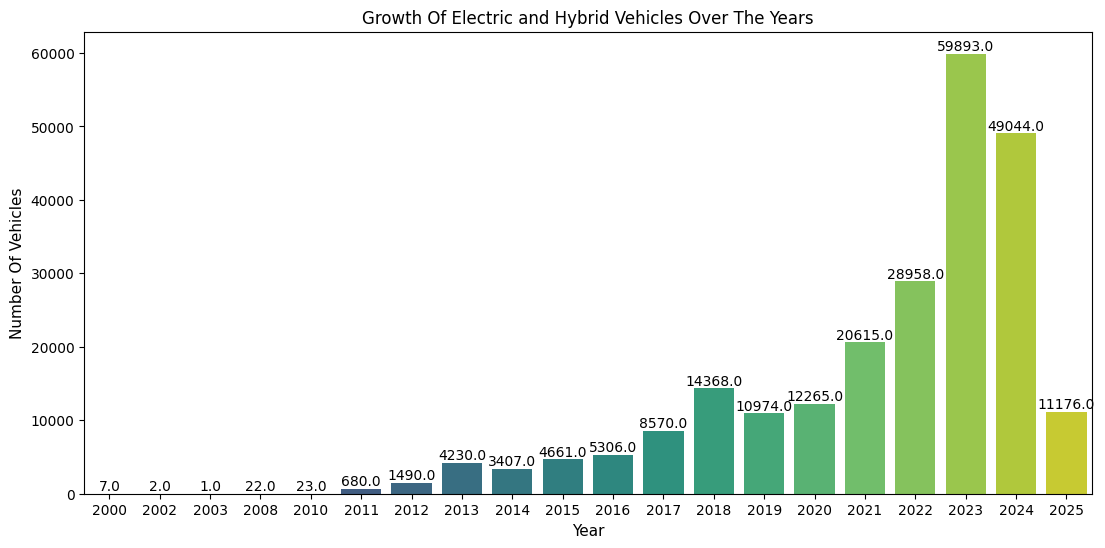

In [ ]:
# Growth Of Electric and Hybrid Vehicles Over The Years

#Grouping the vehicle count by year
yr_counts = df.groupby(["Model Year"]).size().reset_index(name="Vehicle count")

#Plot the figure
plt.figure(figsize=(13,6))
barplot = sns.barplot(yr_counts, x="Model Year", y="Vehicle count", palette="viridis")
plt.xlabel("Year",fontsize=11)
plt.ylabel("Number Of Vehicles", fontsize=11)
plt.title("Growth Of Electric and Hybrid Vehicles Over The Years", fontsize=12)

#Annotate the count over the bars
for p in barplot.patches:
    barplot.annotate(f"{p.get_height()}", (p.get_x() + p.get_width() / 2, p.get_height()), va="bottom", ha="center", fontsize=10)

plt.show()

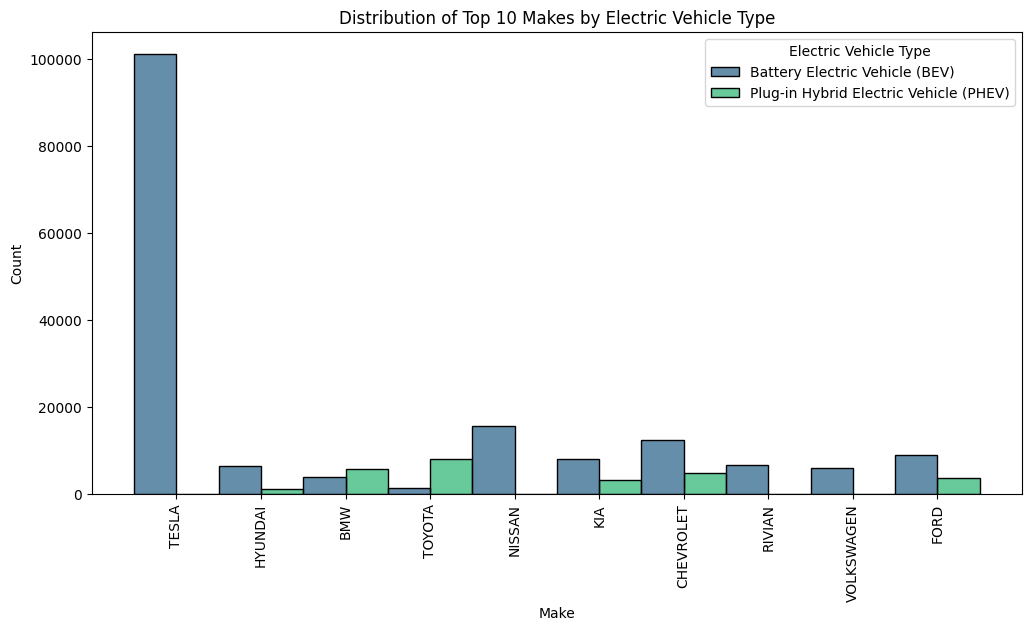

In [ ]:
# Distribution of Top 10 Makes by Electric Vehicle Type

import matplotlib.pyplot as plt
import seaborn as sns

# Get the top 10 makes based on the count of vehicles
top_10_makes = df['Make'].value_counts().nlargest(10).index

# Filter the dataframe to only include rows where Make is in the top 10
df_top_10 = df[df['Make'].isin(top_10_makes)]

# Create the plot
plt.figure(figsize=(12, 6))
sns.histplot(data=df_top_10, x='Make', hue='Electric Vehicle Type', multiple='dodge', palette='viridis', discrete=True)

# Rotate x-axis labels for readability
plt.xticks(rotation=90)

# Add title and labels
plt.title('Distribution of Top 10 Makes by Electric Vehicle Type')
plt.xlabel('Make')
plt.ylabel('Count')

# Show the plot
plt.show()


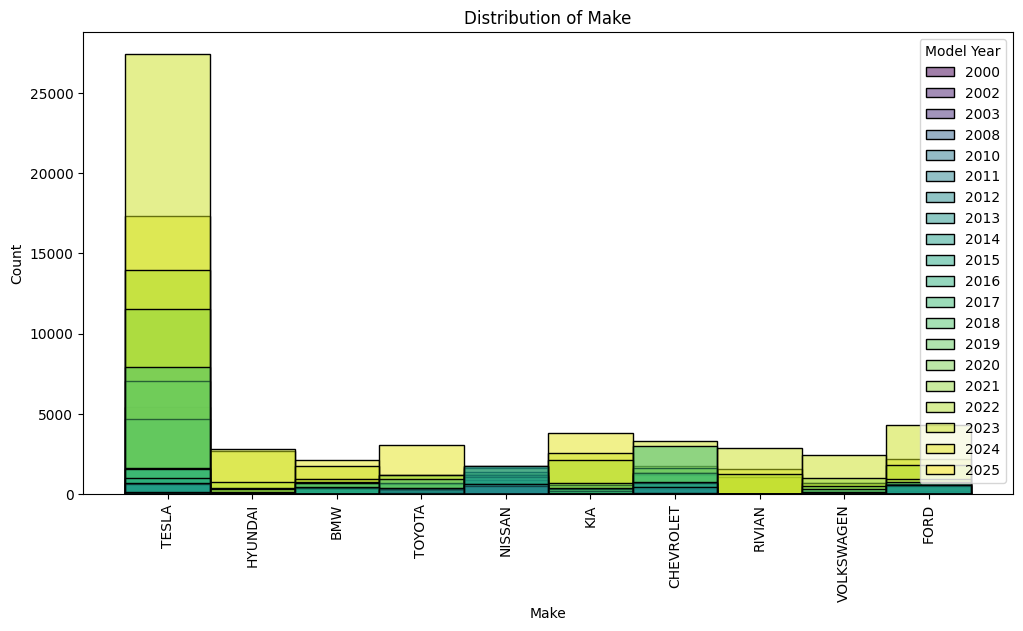

In [ ]:
#Distribution of Electric Range
plt.figure(figsize=(12, 6))
sns.histplot(data =df_top_10, x='Make', bins=50, hue='Model Year', palette='viridis')
plt.xticks(rotation=90)
plt.title('Distribution of Make')
plt.xlabel('Make')
plt.ylabel('Count')
plt.show()

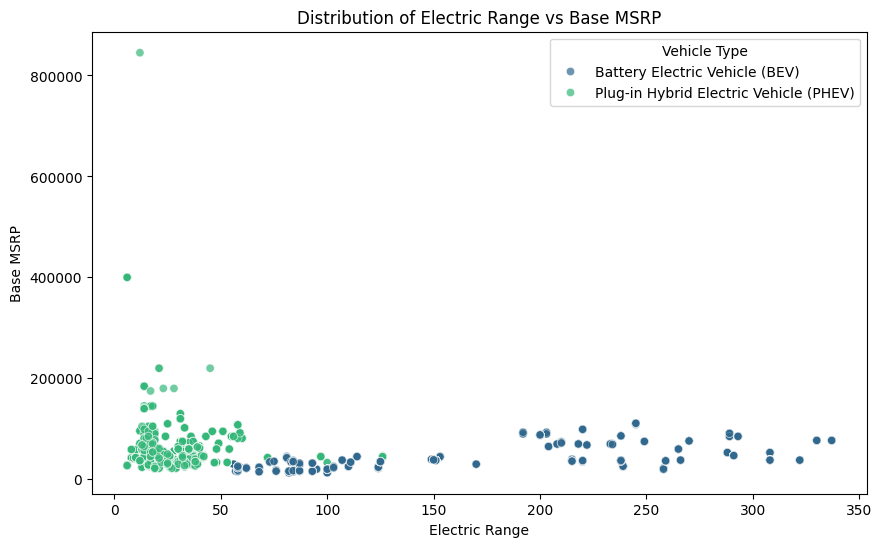

In [ ]:
#Scatter plot for distribution of electric range vs Base MSRP
df_filtered = df[(df['Clean Alternative Fuel Vehicle (CAFV) Eligibility'] != 'Eligibility unknown as battery range has not been researched')]
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_filtered, x='Electric Range', y='Base MSRP', hue='Electric Vehicle Type', palette='viridis', alpha=0.7)
plt.title('Distribution of Electric Range vs Base MSRP')
plt.xlabel('Electric Range')
plt.ylabel('Base MSRP')
plt.legend(title='Vehicle Type')
plt.show()


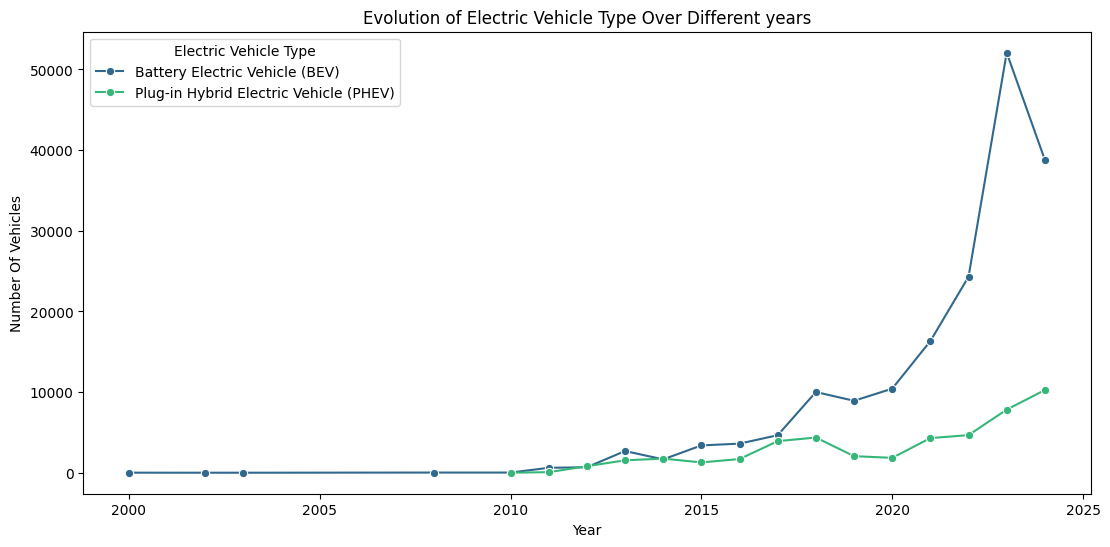

In [ ]:
# Evolution of Electric Vehicle Type Over Different years

arch_per_year = df.groupby(["Electric Vehicle Type", "Model Year"]).size().reset_index(name="Vehicle count")
upto2024 = arch_per_year[arch_per_year["Model Year"] != 2025]

plt.figure(figsize=(13, 6))
lineplot = sns.lineplot(data=upto2024, x="Model Year", y="Vehicle count", hue="Electric Vehicle Type", palette="viridis", marker="o")
plt.xlabel("Year")
plt.ylabel("Number Of Vehicles")
plt.title("Evolution of Electric Vehicle Type Over Different years", fontsize=12)

plt.show()

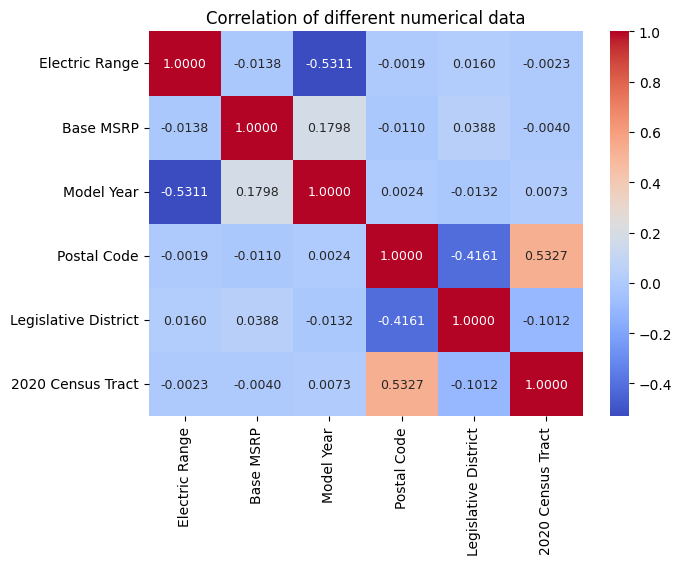

In [ ]:
#Correlation matrix for the numerical data
import seaborn as sns
import matplotlib.pyplot as plt

df_corr = df[['Electric Range', 'Base MSRP', 'Model Year', 'Postal Code', 'Legislative District', '2020 Census Tract']]
corr_matrix = df_corr.corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".4f", annot_kws={"size": 9})
plt.title('Correlation of different numerical data')
plt.show()

## Data Preprocessing

In [36]:
#Drop columns that are not needed
df = df.drop(['2020 Census Tract', 'Electric Utility', 'Vehicle Location', 'Legislative District', 'VIN (1-10)', 'Postal Code'], axis=1)

#Print shape of dataframe after dropping unwanted columns
print(df.shape)

#Print count of null values in the dataframe columns
df.isnull().sum()

(235692, 11)


,0
County,3
City,3
State,0
Model Year,0
Make,0
Model,0
Electric Vehicle Type,0
Clean Alternative Fuel Vehicle (CAFV) Eligibility,0
Electric Range,36
Base MSRP,36


In [37]:
# Categorical Imputation using Mode
df['County'] = df['County'].fillna(df['County'].mode()[0])
df['City'] = df['City'].fillna(df['City'].mode()[0])

# Numerical Imputation using Median
df['Electric Range'] = df['Electric Range'].fillna(df['Electric Range'].median())
df['Base MSRP'] = df['Base MSRP'].fillna(df['Base MSRP'].median())

# Final Check for Missing Values
print(df.isnull().sum())

County                                               0
City                                                 0
State                                                0
Model Year                                           0
Make                                                 0
Model                                                0
Electric Vehicle Type                                0
Clean Alternative Fuel Vehicle (CAFV) Eligibility    0
Electric Range                                       0
Base MSRP                                            0
DOL Vehicle ID                                       0
dtype: int64


In [38]:
#Count the number of rows per state
state_counts = df['State'].value_counts().reset_index(name='Count')
state_counts.columns = ['State', 'Count']
state_counts_sorted = state_counts.sort_values(by='Count', ascending=False)
state_counts_sorted.head(10)


,State,Count
0,WA,235198
1,CA,112
2,VA,62
3,MD,38
4,TX,28
5,CO,21
6,FL,19
7,NC,18
8,GA,15
9,NY,11


In [39]:
#Kept only the rows for WA state as it has the majority of records
df = df[df['State']=='WA']
print("Data of vehicles is from the state of "+df['State'].unique())

#Dropped the state column as now the data is only for WA state
df = df.drop('State',axis=1)
#Print shape of dataframe
df.shape

['Data of vehicles is from the state of WA']


(235198, 10)

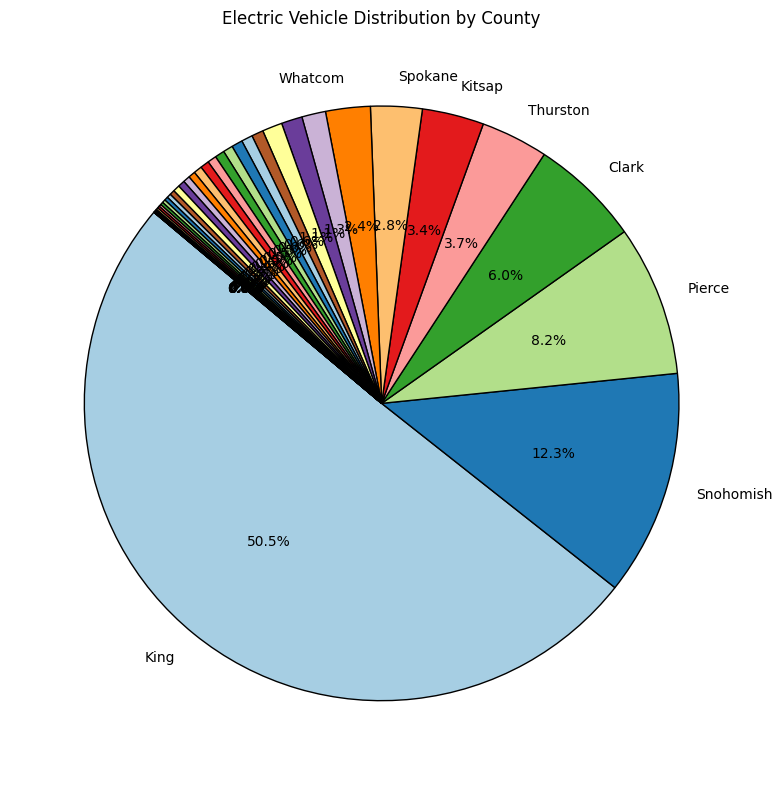

In [12]:
#Distribution of cars across different counties in Washington State

import matplotlib.pyplot as plt

# Group by County and count the number of electric vehicles per county
county_counts = df['County'].value_counts()

# Get the top 10 counties with the highest counts
top_10_counties = county_counts.head(8)

# Create a new list of labels where we only show the names for the top 10 counties
# For counties beyond top 10, the label will be an empty string
labels = [
    county if county in top_10_counties.index else ''  # Show the name only for the top 10 counties
    for county in county_counts.index
]

# Function to format the percentage for the pie chart
def func(pct, allvals):
    return f"{pct:.1f}%"

# Plot the chart
plt.figure(figsize=(8, 8))
wedges, texts, autotexts = plt.pie(
    county_counts.values,
    labels=labels,
    autopct=lambda pct: func(pct, county_counts.values),
    colors=plt.cm.Paired.colors,
    startangle=140,
    wedgeprops={'edgecolor': 'black'}
)

# Add title to the pie chart
plt.title('Electric Vehicle Distribution by County', fontsize=12)

# Display the plot
plt.tight_layout()
plt.show()


## Feature Engineering
Creating new features with Make-Model combination.  
Calculating popularity percentage into a new feature that will act as target variable further for regression problem

In [40]:
#Create a new column combining 'Make' and 'Model'
df['Make-Model'] = df['Make'] + ' ' + df['Model']

units_sold = df.groupby(['Make', 'Model', 'County'])['DOL Vehicle ID'].transform('count')

#Calculate the Popularity percentage and add it to a new column
df['Popularity Percentage'] = (units_sold / units_sold.max()) * 100

df.head()

,County,City,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,DOL Vehicle ID,Make-Model,Popularity Percentage
0,King,Seattle,2019,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,220.0,37000.0,477309682,TESLA MODEL 3,72.233789
1,Kitsap,Poulsbo,2020,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,291.0,47000.0,109705683,TESLA MODEL Y,4.134444
2,Kitsap,Olalla,2023,HYUNDAI,IONIQ 5,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,40000.0,230390492,HYUNDAI IONIQ 5,0.725015
3,Kitsap,Seabeck,2021,BMW,X5,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,30.0,60000.0,267929112,BMW X5,0.293724
4,Thurston,Rainier,2023,TOYOTA,RAV4 PRIME,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,42.0,45000.0,236505139,TOYOTA RAV4 PRIME,0.553986


In [41]:
#Check the data types
df.dtypes

,0
County,object
City,object
Model Year,int64
Make,object
Model,object
Electric Vehicle Type,object
Clean Alternative Fuel Vehicle (CAFV) Eligibility,object
Electric Range,float64
Base MSRP,float64
DOL Vehicle ID,int64


## Standard Scaling
For numerical data that are on different scale, standardize them. E.g., Base MSRP and Electric Range

In [42]:
df[['County','City','Make','Model','Model Year','Electric Vehicle Type','Clean Alternative Fuel Vehicle (CAFV) Eligibility', 'Make-Model']]=df[['County','City','Make','Model','Model Year','Electric Vehicle Type','Clean Alternative Fuel Vehicle (CAFV) Eligibility', 'Make-Model']].astype('category')

# Create a mask for non-zero values
non_zero_mask = df['Electric Range'] > 0

# Extract the non-zero values for scaling
electric_range_non_zero = df.loc[non_zero_mask, 'Electric Range'].values.reshape(-1, 1)

# Scale only the non-zero electric range values
scaler = StandardScaler()
electric_range_scaled = scaler.fit_transform(electric_range_non_zero)

# Replace the scaled values back into the original DataFrame
df.loc[non_zero_mask, 'Electric Range'] = electric_range_scaled.flatten()

# Impute the zero values (0 or NaN) with the median of the non-zero values or any other imputation method
# We first replace zeros with NaN to treat them as missing values for imputation
df['Electric Range'] = df['Electric Range'].replace(0, np.nan)

# Impute missing values (NaNs) with the median of non-zero values
imputer = SimpleImputer(strategy='median')
df['Electric Range'] = imputer.fit_transform(df[['Electric Range']])

# Scale Base MSRP
scaler_base = StandardScaler()
df['Base MSRP'] = scaler_base.fit_transform(df[['Base MSRP']])

print(df.dtypes)

df.head()


County                                               category
City                                                 category
Model Year                                           category
Make                                                 category
Model                                                category
Electric Vehicle Type                                category
Clean Alternative Fuel Vehicle (CAFV) Eligibility    category
Electric Range                                        float64
Base MSRP                                             float64
DOL Vehicle ID                                          int64
Make-Model                                           category
Popularity Percentage                                 float64
dtype: object


,County,City,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,DOL Vehicle ID,Make-Model,Popularity Percentage
0,King,Seattle,2019,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,1.079898,-0.629206,477309682,TESLA MODEL 3,72.233789
1,Kitsap,Poulsbo,2020,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,1.801150,-0.005324,109705683,TESLA MODEL Y,4.134444
2,Kitsap,Olalla,2023,HYUNDAI,IONIQ 5,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,-0.423556,-0.442041,230390492,HYUNDAI IONIQ 5,0.725015
3,Kitsap,Seabeck,2021,BMW,X5,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,-0.850212,0.805724,267929112,BMW X5,0.293724
4,Thurston,Rainier,2023,TOYOTA,RAV4 PRIME,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,-0.728310,-0.130100,236505139,TOYOTA RAV4 PRIME,0.553986


## Data Mining Techniques

### 1. Association Rule Mining
Association rule mining used to discover any relationships, patterns, or correlations between Make-Model and county to see if certain make models are more popular in certain counties or not

In [48]:
from mlxtend.preprocessing import TransactionEncoder

#create subset for features amongst which association rule mining is to be performed
data_subset = df[['Make-Model', 'County']]

# Preprocess data into list of transactions
transactions = data_subset.apply(lambda row: row.astype(str).values.tolist(), axis=1).tolist()

# Convert the transactions to one-hot encoded format
encoder = TransactionEncoder()
encoded_data = encoder.fit_transform(transactions)

# Create a DataFrame for the encoded data
encoded_df = pd.DataFrame(encoded_data, columns=encoder.columns_)

encoded_df.head()


,ACURA ZDX,ALFA ROMEO TONALE,AUDI A3,AUDI A7 E,AUDI A8 E,AUDI E-TRON,AUDI E-TRON GT,AUDI E-TRON SPORTBACK,AUDI Q4,AUDI Q5,...,VOLVO V60,VOLVO XC40,VOLVO XC60,VOLVO XC90,WHEEGO ELECTRIC CARS WHEEGO,Wahkiakum,Walla Walla,Whatcom,Whitman,Yakima
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [49]:
pd.set_option('display.max_colwidth', None)

# Apply the Apriori algorithm to find frequent itemsets
from mlxtend.frequent_patterns import apriori, association_rules

# Apply the Apriori algorithm with a minimum support of 0.05
frequent_itemsets = apriori(encoded_df, min_support=0.05, use_colnames=True)

frequent_itemsets

,support,itemsets
0,0.059920,(Clark)
1,0.504728,(King)
2,0.058691,(NISSAN LEAF)
3,0.081871,(Pierce)
4,0.122510,(Snohomish)
5,0.152943,(TESLA MODEL 3)
6,0.208960,(TESLA MODEL Y)
7,0.082603,"(King, TESLA MODEL 3)"
8,0.114355,"(King, TESLA MODEL Y)"


In [50]:
# Generate association rules from the frequent itemsets
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)

# Display the rules
rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(King),(TESLA MODEL 3),0.504728,0.152943,0.082603,0.163658,1.070055,1.0,0.005408,1.012811,0.132187,0.143640,0.012649,0.351872
1,(TESLA MODEL 3),(King),0.152943,0.504728,0.082603,0.540087,1.070055,1.0,0.005408,1.076881,0.077290,0.143640,0.071393,0.351872
2,(King),(TESLA MODEL Y),0.504728,0.208960,0.114355,0.226567,1.084260,1.0,0.008887,1.022765,0.156907,0.190803,0.022258,0.386912
3,(TESLA MODEL Y),(King),0.208960,0.504728,0.114355,0.547256,1.084260,1.0,0.008887,1.093934,0.098240,0.190803,0.085868,0.386912


In [51]:
# Filter rules based on lift and confidence (optional)
filtered_rules = rules[(rules['lift'] > 1) & (rules['confidence'] > 0.5)]

# Display filtered rules
filtered_rules


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
1,(TESLA MODEL 3),(King),0.152943,0.504728,0.082603,0.540087,1.070055,1.0,0.005408,1.076881,0.07729,0.143640,0.071393,0.351872
3,(TESLA MODEL Y),(King),0.208960,0.504728,0.114355,0.547256,1.084260,1.0,0.008887,1.093934,0.09824,0.190803,0.085868,0.386912


In [52]:
# Evaluate the support, confidence, lift for the rules
top_support_rules = filtered_rules.sort_values(by='support', ascending=False)
print(top_support_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head())

       antecedents consequents   support  confidence      lift
3  (TESLA MODEL Y)      (King)  0.114355    0.547256  1.084260
1  (TESLA MODEL 3)      (King)  0.082603    0.540087  1.070055


Analysis:
Targeting King County: King County has a notable proportion of customers buying TESLA MODEL 3 and TESLA MODEL Y, and targeting this region could be effective for future campaigns or sales strategies.

Product Availability or Promotions: Given the higher likelihood of TESLA vehicle purchases in King County, there could be potential for tailored promotions, events, or product availability targeted specifically at King County.

### Clustering
Identify the clusters and then identify the vehicles falling into those clusters.   
Identified the most popular vehicle by Make, Model, price, electric range and greographical location in that cluster.   
Noted the number of vehicles per cluster too.

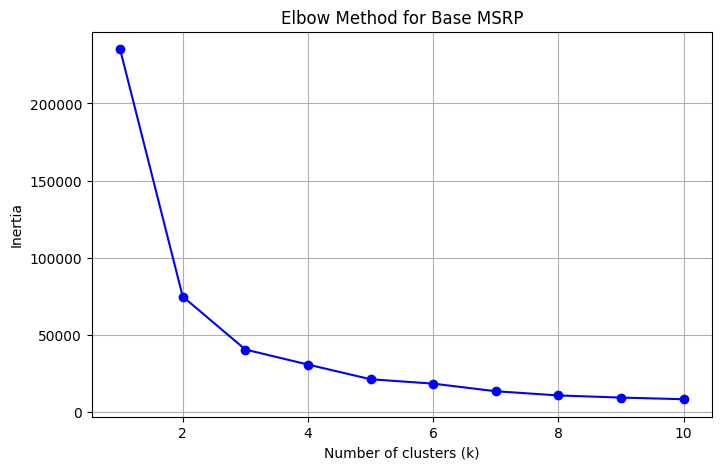

In [58]:
#Identifying clusters based on price
X = df[['Base MSRP']].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow method
inertia = []
k_range = range(1, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plotting the elbow curve
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, 'bo-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Base MSRP')
plt.grid(True)
plt.show()

Selected 4 as the value of k to cluster vehicles into price range of Low Price, Medium Price, High Price, and Very High Price.  
A 5th cluster would include all vehicle where electric range is unknown.

In [43]:
import pandas as pd
from sklearn.cluster import KMeans

# Filtered the data frame to only include cars where Electric Range is known
df_filtered = df[df['Clean Alternative Fuel Vehicle (CAFV) Eligibility'] != 'Eligibility unknown as battery range has not been researched'].copy()

# Clustering based on price (Base MSRP) - Low, Medium, High, Very High
kmeans_price = KMeans(n_clusters=4, random_state=42)
df_filtered['Price Cluster'] = kmeans_price.fit_predict(df_filtered[['Base MSRP']])

# For each price cluster, perform clustering based on Electric Range (Low, High)
def cluster_by_electric_range(price_cluster, df_filtered):

    cluster_data = df_filtered[df_filtered['Price Cluster'] == price_cluster].copy()

    # Applied KMeans clustering on Electric Range within the price cluster
    kmeans_range = KMeans(n_clusters=2, random_state=42)
    cluster_data['Range Cluster'] = kmeans_range.fit_predict(cluster_data[['Electric Range']])

    # Update the main dataframe with the cluster results
    df_filtered.loc[df_filtered['Price Cluster'] == price_cluster, 'Range Cluster'] = cluster_data['Range Cluster']
    return df_filtered

# Apply the range clustering for each price cluster
for price_cluster in df_filtered['Price Cluster'].unique():
    df_filtered = cluster_by_electric_range(price_cluster, df_filtered)

#Create a copy of the original dataframe and merge the cluster information to it so that inverse transform can be performed on Base MSRP and Electric Range
df_clustering = df.copy()
df_clustering = pd.merge(df_clustering, df_filtered[['DOL Vehicle ID','Price Cluster', 'Range Cluster']], on='DOL Vehicle ID', how='left')

#Add the cars with unknown electric range to -1 cluster
df_clustering['Price Cluster'] = df_clustering['Price Cluster'].fillna('-1')
df_clustering['Range Cluster'] = df_clustering['Range Cluster'].fillna('-1')

#Perform inverse transform to bring back original values of Base MSRP and Electric Range
df_clustering[['Electric Range']] = scaler.inverse_transform(df[['Electric Range']])
df_clustering[['Base MSRP']] = scaler_base.inverse_transform(df[['Base MSRP']])
df_clustering.loc[df_clustering['Clean Alternative Fuel Vehicle (CAFV) Eligibility'] == 'Eligibility unknown as battery range has not been researched', 'Electric Range'] = 0

#Print the top 5 rows showing the Price and Electric Range Clusters
df_clustering.head()


,County,City,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,DOL Vehicle ID,Make-Model,Popularity Percentage,Price Cluster,Range Cluster
0,King,Seattle,2019,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,220.0,37000.0,477309682,TESLA MODEL 3,72.233789,3.0,1.0
1,Kitsap,Poulsbo,2020,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,291.0,47000.0,109705683,TESLA MODEL Y,4.134444,0.0,1.0
2,Kitsap,Olalla,2023,HYUNDAI,IONIQ 5,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,40000.0,230390492,HYUNDAI IONIQ 5,0.725015,-1,-1
3,Kitsap,Seabeck,2021,BMW,X5,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,30.0,60000.0,267929112,BMW X5,0.293724,0.0,0.0
4,Thurston,Rainier,2023,TOYOTA,RAV4 PRIME,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,42.0,45000.0,236505139,TOYOTA RAV4 PRIME,0.553986,0.0,0.0


In [44]:
# Group by Price Cluster and Range Cluster
cluster_stats = df_clustering.groupby(['Price Cluster', 'Range Cluster']).agg(
    min_price=('Base MSRP', 'min'),
    max_price=('Base MSRP', 'max'),
    min_range=('Electric Range', 'min'),
    max_range=('Electric Range', 'max'),
    num_cars=('Base MSRP', 'size')  # Counting number of cars in the cluster
).reset_index()

# Adding most popular car information to each cluster
def get_most_popular_car(cluster_data):
    # Find the most popular Make and Model in the cluster
    most_popular_car = cluster_data.groupby(['Make', 'Model'], observed=False).size().idxmax()
    # Get the details of the most popular car (Price and Electric Range)
    most_popular_car_data = cluster_data[(cluster_data['Make'] == most_popular_car[0]) &
                                         (cluster_data['Model'] == most_popular_car[1])]
    most_popular_car_price = most_popular_car_data['Base MSRP'].min()
    most_popular_car_range = most_popular_car_data['Electric Range'].min()
    most_popular_car_ev_type = most_popular_car_data['Electric Vehicle Type'].mode()[0]
    return most_popular_car, most_popular_car_price, most_popular_car_range, most_popular_car_ev_type

# Print cluster statistics along with most popular car details
for _, row in cluster_stats.iterrows():
    # Get the cluster data
    cluster_data = df_clustering[(df_clustering['Price Cluster'] == row['Price Cluster']) &
                           (df_clustering['Range Cluster'] == row['Range Cluster'])]

    # Get most popular car info
    most_popular_car, most_popular_car_price, most_popular_car_range, most_popular_car_ev_type = get_most_popular_car(cluster_data)

    print(f"Price Cluster: {row['Price Cluster']}, Range Cluster: {row['Range Cluster']}:")
    print(f"  Min Price: {row['min_price']}")
    print(f"  Max Price: {row['max_price']}")
    print(f"  Min Electric Range: {row['min_range']}")
    print(f"  Max Electric Range: {row['max_range']}")
    print(f"  Total Number of Cars: {row['num_cars']}")

    print(f"  Most Popular Car in this Cluster: Make: {most_popular_car[0]}, Model: {most_popular_car[1]}, Price($): {most_popular_car_price}, Electric Range(miles): {most_popular_car_range}, Vehicle Type: {most_popular_car_ev_type}")
    print("-" * 40)


Price Cluster: 0.0, Range Cluster: 0.0:
  Min Price: 43700.0
  Max Price: 63000.0
  Min Electric Range: 8.0
  Max Electric Range: 153.0
  Total Number of Cars: 14384
  Most Popular Car in this Cluster: Make: TOYOTA, Model: RAV4 PRIME, Price($): 44000.0, Electric Range(miles): 42.0, Vehicle Type: Plug-in Hybrid Electric Vehicle (PHEV)
----------------------------------------
Price Cluster: 0.0, Range Cluster: 1.0:
  Min Price: 47000.0
  Max Price: 59900.0
  Min Electric Range: 265.0
  Max Electric Range: 308.0
  Total Number of Cars: 2555
  Most Popular Car in this Cluster: Make: TESLA, Model: MODEL Y, Price($): 47000.0, Electric Range(miles): 291.0, Vehicle Type: Battery Electric Vehicle (BEV)
----------------------------------------
Price Cluster: 1.0, Range Cluster: 0.0:
  Min Price: 65000.0
  Max Price: 110950.0
  Min Electric Range: 192.0
  Max Electric Range: 337.0
  Total Number of Cars: 10376
  Most Popular Car in this Cluster: Make: TESLA, Model: MODEL S, Price($): 69900.0, Ele

In [47]:
import plotly.express as px

fig = px.scatter(
    df_clustering,
    x='Base MSRP',
    y='Electric Range',
    color='Price Cluster',
    symbol='Range Cluster',
    hover_data=['Make', 'Model', 'Electric Vehicle Type'],
    title='EV Clusters: Base MSRP vs Electric Range'
)
fig.show()


Output hidden; open in https://colab.research.google.com to view.

#### Customer Segmentation for Marketing and Sales:

Price-Sensitive Consumers (Low Price Range - Price Cluster 0, Range Cluster 0):  

Insight: The TOYOTA RAV4 PRIME is the most popular vehicle in this cluster. With an electric range of 42 miles and a price around $44,000, it appeals to consumers looking for affordable plug-in hybrid electric vehicles (PHEVs).

Mid-Range Consumers (Medium Price Range - Price Cluster 0, Range Cluster 1):  

Insight: The TESLA MODEL Y leads in this segment, with an electric range of 291 miles. Consumers here are willing to spend more on an electric vehicle (BEV) with longer range and better technology.  

Luxury Consumers (High Price Range - Price Cluster 1, Range Cluster 0):  

Insight: The TESLA MODEL S, with an electric range of 208 miles, is popular in this segment. Consumers here value both luxury and performance in BEVs.  

Premium Consumers (High Price Range - Price Cluster 1, Range Cluster 1):  

Insight: The VOLVO XC90 PHEV leads this segment, appealing to consumers who prioritize luxury, performance, and moderate electric range (13 miles).  

Budget-Conscious Buyers (Low Price Range - Price Cluster 2, Range Cluster 0):  

Insight: The TOYOTA PRIUS PRIME, a popular plug-in hybrid, offers an electric range of 25 miles at a starting price of $30,000. This segment is more budget-sensitive while still seeking sustainable transportation options.  

Economical Long-Range Buyers (Medium Price Range - Price Cluster 2, Range Cluster 1):  

Insight: The KIA NIRO, a BEV with a strong electric range of 239 miles, stands out in this cluster, offering excellent value for consumers who prioritize longer electric ranges.  

Mass-Market EV Buyers (Mid-Range Price Range - Price Cluster 3, Range Cluster 0):  

Insight: The NISSAN LEAF, a popular BEV with an electric range of 73 miles, leads in this cluster. It appeals to consumers looking for an affordable, environmentally friendly vehicle with moderate electric range.  

Tech-Savvy, Range-Focused Consumers (Mid-Range Price Range - Price Cluster 3, Range Cluster 1):  

Insight: The TESLA MODEL 3 is the most popular vehicle in this segment, offering a longer electric range (215 miles) at a mid-range price point.  

Unknown Range or Outlier Vehicles (Price Cluster -1, Range Cluster -1):  

Insight: The TESLA MODEL Y is the most popular vehicle here, but with an electric range of 0 miles, indicating these cars likely belong to another category or are part of outliers in the data. This may represent missing or incomplete data for some vehicles.  

#### Growth Opportunities for EV Infrastructure:  
Expanding Charging Infrastructure for Long-Range EVs: With increasing adoption of BEVs like TESLA (Price Cluster 1, Range Cluster 1), the demand for charging infrastructure, particularly in urban areas, is expected to grow.


### Classification  

Features: Make, Model, Model Year  
Target: Clean Alternative Fuel Vehicle (CAFV) Eligibility.   
**Decision Tree Classifier:** Selected for its capability to model non-linear relationships and provide intuitive, visual representations of decision rules, which enhance interpretability.  
**Random Forest Classifier:** Chosen as an ensemble method that aggregates multiple decision trees to improve classification accuracy and reduce the risk of overfitting, offering robust performance across various datasets.  
**Logistic Regression:** Preferred for its simplicity, efficiency, and ease of interpretation in binary classification tasks. It serves as a strong baseline model and is particularly useful when feature relationships are approximately linear.  
**Support Vector Classifier (SVC):** Selected for its effectiveness in handling high-dimensional feature spaces and its ability to construct complex decision boundaries, making it suitable for datasets where classes are not linearly separable.


In [ ]:
from sklearn.model_selection import train_test_split
import pandas as pd

def prepare_data(df):
    """
    Splits the data into training and testing sets and applies one-hot encoding.

    Parameters:
        df (pd.DataFrame): Original dataset

    Returns:
        X_train_encoded (pd.DataFrame): Encoded training features
        y_train (pd.Series): Training labels
        X_test_encoded (pd.DataFrame): Encoded testing features
        y_test (pd.Series): Testing labels
    """
    # Split by unique Make, Model, Model Year combinations
    train_makes, test_makes = train_test_split(
        df[['Make', 'Model', 'Model Year']].drop_duplicates(),
        test_size=0.2,
        random_state=42
    )

    # Merge back to get full training and testing data
    train_data = df.merge(train_makes, on=['Make', 'Model', 'Model Year'], how='inner')
    test_data = df.merge(test_makes, on=['Make', 'Model', 'Model Year'], how='inner')

    # Features and target
    X_train = train_data[['Make', 'Model', 'Model Year']]
    y_train = train_data['Clean Alternative Fuel Vehicle (CAFV) Eligibility']
    X_test = test_data[['Make', 'Model', 'Model Year']]
    y_test = test_data['Clean Alternative Fuel Vehicle (CAFV) Eligibility']

    # One-hot encoding
    X_train_encoded = pd.get_dummies(X_train, drop_first=True)
    X_test_encoded = pd.get_dummies(X_test, drop_first=True)

    # Align to make sure both train and test have the same columns
    X_train_encoded, X_test_encoded = X_train_encoded.align(
        X_test_encoded, join='left', axis=1, fill_value=0
    )
    return X_train, X_train_encoded.astype(float), y_train, X_test_encoded.astype(float), y_test


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pandas as pd

def evaluate_model(model_name, y_test, y_pred):
    """
    Evaluates a classification model using accuracy, confusion matrix, and classification report.

    Parameters:
        model_name (str): Name of the model (e.g. "Logistic Regression", "SVM" etc)
        y_test (pd.Series): True labels
        y_pred (array-like): Predicted labels
    """
    print(f"\nModel: {model_name}")
    print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')

    label_map = {
        'Clean Alternative Fuel Vehicle Eligible': 'Eligible',
        'Eligibility unknown as battery range has not been researched': 'Unknown',
        'Not eligible due to low battery range': 'Not Eligible'
    }
    label_order = list(label_map.values())

    y_test_named = y_test.replace(label_map)
    y_pred_named = pd.Series(y_pred).replace(label_map)

    # Confusion Matrix
    cm = confusion_matrix(y_test_named, y_pred_named, labels=label_order)

    # Plot heatmap
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_order,
                yticklabels=label_order)
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

    print("Classification Report:")
    print(classification_report(y_test, y_pred))


### Decision Tree Classifier
Find the best hyperparameters that fit the training data  
Train the model on the best set of hyperparameters and then check the Accuracy score  
Display the confusion matrix and the classification report
Calculate the cross validation scores using GroupKFold

In [ ]:
#Decision Tree Classifier hyperparameter testing

X_train, X_train_encoded, y_train, X_test_encoded, y_test = prepare_data(df)

dt = DecisionTreeClassifier(random_state=42)

param_dist = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None] + list(range(5, 31)),
    'min_samples_split': randint(2, 11),
    'min_samples_leaf': randint(1, 5),
    'class_weight': [None, 'balanced']
}

random_search = RandomizedSearchCV(
    estimator=dt,
    param_distributions=param_dist,
    n_iter=50,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

random_search.fit(X_train_encoded, y_train)

best_dt = random_search.best_estimator_
best_params = random_search.best_params_

print("Best Hyperparameters (RandomizedSearchCV):", best_params)



Fitting 5 folds for each of 50 candidates, totalling 250 fits


/Users/shonie/.pyenv/versions/3.13.1/lib/python3.13/site-packages/joblib/externals/loky/backend/fork_exec.py:38: DeprecationWarning: This process (pid=75180) is multi-threaded, use of fork() may lead to deadlocks in the child.
  pid = os.fork()
/Users/shonie/.pyenv/versions/3.13.1/lib/python3.13/site-packages/joblib/externals/loky/backend/fork_exec.py:38: DeprecationWarning: This process (pid=75180) is multi-threaded, use of fork() may lead to deadlocks in the child.
  pid = os.fork()
/Users/shonie/.pyenv/versions/3.13.1/lib/python3.13/site-packages/joblib/externals/loky/backend/fork_exec.py:38: DeprecationWarning: This process (pid=75180) is multi-threaded, use of fork() may lead to deadlocks in the child.
  pid = os.fork()
/Users/shonie/.pyenv/versions/3.13.1/lib/python3.13/site-packages/joblib/externals/loky/backend/fork_exec.py:38: DeprecationWarning: This process (pid=75180) is multi-threaded, use of fork() may lead to deadlocks in the child.
  pid = os.fork()
/Users/shonie/.pyenv

Best Hyperparameters (RandomizedSearchCV): {'class_weight': None, 'criterion': 'gini', 'max_depth': 30, 'min_samples_leaf': 2, 'min_samples_split': 10}



Model: Decision Tree Classifier
Accuracy: 0.8051


/var/folders/lj/7bdznky91854yv4wc8x1pt8m0000gp/T/ipykernel_75180/1332129848.py:25: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  y_test_named = y_test.replace(label_map)


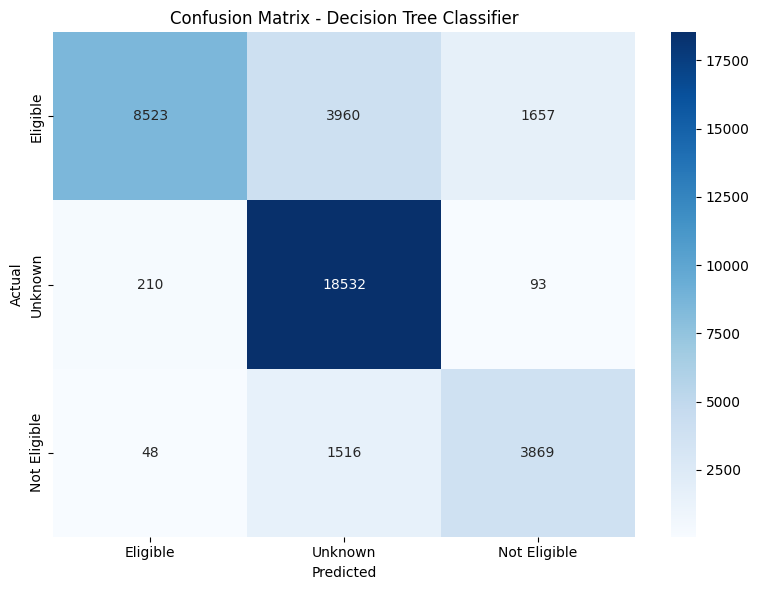

Classification Report:
                                                              precision    recall  f1-score   support

                     Clean Alternative Fuel Vehicle Eligible       0.97      0.60      0.74     14140
Eligibility unknown as battery range has not been researched       0.77      0.98      0.87     18835
                       Not eligible due to low battery range       0.69      0.71      0.70      5433

                                                    accuracy                           0.81     38408
                                                   macro avg       0.81      0.77      0.77     38408
                                                weighted avg       0.83      0.81      0.80     38408



In [ ]:
from sklearn.tree import DecisionTreeClassifier

X_train, X_train_encoded, y_train, X_test_encoded, y_test = prepare_data(df)

best_dt = DecisionTreeClassifier(
    class_weight=None,
    criterion='gini',
    max_depth=30,
    min_samples_leaf=2,
    min_samples_split=10,
    random_state=42
)
best_dt.fit(X_train_encoded, y_train)

# Predict on the test set
y_pred_dt = best_dt.predict(X_test_encoded)
y_score_dt = best_dt.predict_proba(X_test_encoded)

evaluate_model('Decision Tree Classifier', y_test, y_pred_dt)



In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GroupKFold
from sklearn.model_selection import cross_val_score
import numpy as np

groups = X_train['Make'].astype(str) + '_' + X_train['Model'].astype(str) + '_' + X_train['Model Year'].astype(str)

# Set up GroupKFold (e.g., 5 splits)
group_kfold = GroupKFold(n_splits=5)

# Perform cross-validation with GroupKFold
dt_cv_scores = cross_val_score(best_dt, X_train_encoded, y_train, cv=group_kfold, groups=groups, scoring='accuracy')

print("Cross-validation scores (GroupKFold):", dt_cv_scores)
print("Average CV Accuracy (GroupKFold):", dt_cv_scores.mean())


Cross-validation scores (GroupKFold): [0.8774582  0.72186087 0.83464607 0.90423802 0.8513644 ]
Average CV Accuracy (GroupKFold): 0.8379135118654404


### Random Forest Classifier
Find best hyperparameters  
Train model on most optimum found hyperparameters  
Display the confusion matrix, classification report  
Perform GroupK Fold cross validation

In [ ]:
#Random Forest Hyperparameter testing

X_train, X_train_encoded, y_train, X_test_encoded, y_test = prepare_data(df)

# --- Grid Search CV ---

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'max_features': ['sqrt', 'log2'],
    'class_weight': ['balanced']
}

rf = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(estimator=rf, param_grid=param_grid,
                           scoring='accuracy', cv=3, n_jobs=-1, verbose=2)

grid_search.fit(X_train_encoded, y_train)

print("Best Parameters:", grid_search.best_params_)

# --- Evaluate the Best Model ---

best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test_encoded)

print(f"\nAccuracy: {accuracy_score(y_test, y_pred)}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Fitting 3 folds for each of 108 candidates, totalling 324 fits


/Users/shonie/.pyenv/versions/3.13.1/lib/python3.13/site-packages/joblib/externals/loky/backend/fork_exec.py:38: DeprecationWarning: This process (pid=43233) is multi-threaded, use of fork() may lead to deadlocks in the child.
  pid = os.fork()
/Users/shonie/.pyenv/versions/3.13.1/lib/python3.13/site-packages/joblib/externals/loky/backend/fork_exec.py:38: DeprecationWarning: This process (pid=43233) is multi-threaded, use of fork() may lead to deadlocks in the child.
  pid = os.fork()
/Users/shonie/.pyenv/versions/3.13.1/lib/python3.13/site-packages/joblib/externals/loky/backend/fork_exec.py:38: DeprecationWarning: This process (pid=43233) is multi-threaded, use of fork() may lead to deadlocks in the child.
  pid = os.fork()
/Users/shonie/.pyenv/versions/3.13.1/lib/python3.13/site-packages/joblib/externals/loky/backend/fork_exec.py:38: DeprecationWarning: This process (pid=43233) is multi-threaded, use of fork() may lead to deadlocks in the child.
  pid = os.fork()
/Users/shonie/.pyenv

[CV] END class_weight=balanced, max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   9.3s
[CV] END class_weight=balanced, max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   9.4s
[CV] END class_weight=balanced, max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   9.5s
[CV] END class_weight=balanced, max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   9.6s
[CV] END class_weight=balanced, max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   9.6s
[CV] END class_weight=balanced, max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   9.6s
[CV] END class_weight=balanced, max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=  16.8s


Model: Random Forest
Accuracy: 0.8592


/var/folders/lj/7bdznky91854yv4wc8x1pt8m0000gp/T/ipykernel_75180/1332129848.py:25: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  y_test_named = y_test.replace(label_map)


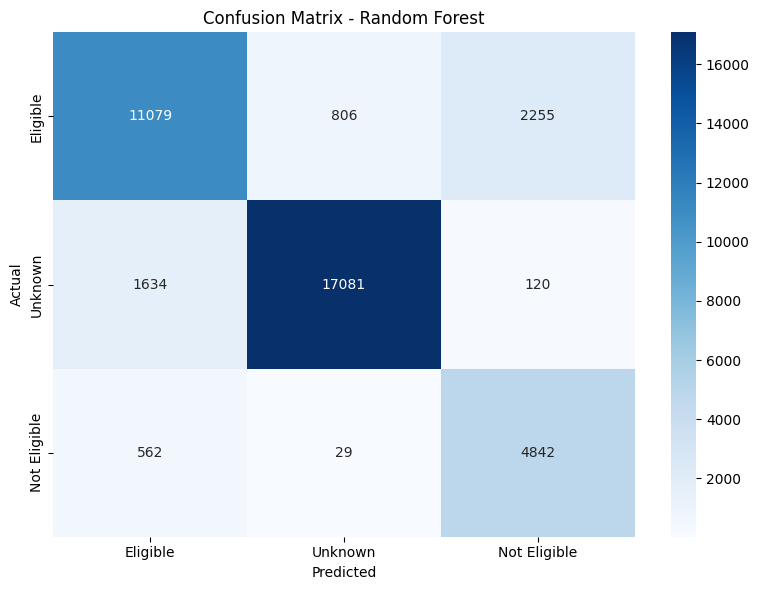

Classification Report:
                                                              precision    recall  f1-score   support

                     Clean Alternative Fuel Vehicle Eligible       0.83      0.78      0.81     14140
Eligibility unknown as battery range has not been researched       0.95      0.91      0.93     18835
                       Not eligible due to low battery range       0.67      0.89      0.77      5433

                                                    accuracy                           0.86     38408
                                                   macro avg       0.82      0.86      0.83     38408
                                                weighted avg       0.87      0.86      0.86     38408



In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X_train, X_train_encoded, y_train, X_test_encoded, y_test = prepare_data(df)

# Fit the Random Forest Classifier
best_rf = RandomForestClassifier(n_estimators=200,
    max_depth=None,
    max_features='log2',
    min_samples_leaf=2,
    min_samples_split=5,
    class_weight='balanced',
    random_state=42)
best_rf.fit(X_train_encoded, y_train)

# Evaluate on the test set
y_pred_rf = best_rf.predict(X_test_encoded)
y_score_rf = best_rf.predict_proba(X_test_encoded)

evaluate_model('Random Forest', y_test, y_pred_rf)

In [ ]:
# Create the same group identifiers
groups = X_train['Make'].astype(str) + '_' + X_train['Model'].astype(str) + '_' + X_train['Model Year'].astype(str)

# Create GroupKFold object
gkf = GroupKFold(n_splits=5)

# Cross-validation with F1 macro scoring
rf_cv_scores = cross_val_score(best_rf, X_train_encoded, y_train,
                            cv=gkf.split(X_train_encoded, y_train, groups),
                            scoring='accuracy')

print(f'GroupKFold F1 scores (Random Forest): {rf_cv_scores}')
print(f'Mean GroupKFold F1 (Random Forest): {rf_cv_scores.mean()}')


GroupKFold F1 scores (Random Forest): [0.89389705 0.83423954 0.9132832  0.87641648 0.88220946]
Mean GroupKFold F1 (Random Forest): 0.8800091468062401


### Logistic Regresssion
Find best hyperparameters  
Train model on most optimum found hyperparameters  
Display the confusion matrix, classification report  
Perform GroupK Fold cross validation

In [ ]:
#Logistic Regression Hyperparameter testing

X_train, X_train_encoded, y_train, X_test_encoded, y_test = prepare_data(df)

# Define the model
clf = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)

# Define the parameter grid
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga']
}

# GridSearchCV setup
grid_search = GridSearchCV(
    estimator=clf,
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Fit to training data
grid_search.fit(X_train_encoded, y_train)

# Show best hyperparameters
print("Best Hyperparameters (Logistic Regression):", grid_search.best_params_)


Fitting 5 folds for each of 20 candidates, totalling 100 fits


/Users/shonie/.pyenv/versions/3.13.1/lib/python3.13/site-packages/joblib/externals/loky/backend/fork_exec.py:38: DeprecationWarning: This process (pid=75180) is multi-threaded, use of fork() may lead to deadlocks in the child.
  pid = os.fork()
/Users/shonie/.pyenv/versions/3.13.1/lib/python3.13/site-packages/joblib/externals/loky/backend/fork_exec.py:38: DeprecationWarning: This process (pid=75180) is multi-threaded, use of fork() may lead to deadlocks in the child.
  pid = os.fork()
/Users/shonie/.pyenv/versions/3.13.1/lib/python3.13/site-packages/joblib/externals/loky/backend/fork_exec.py:38: DeprecationWarning: This process (pid=75180) is multi-threaded, use of fork() may lead to deadlocks in the child.
  pid = os.fork()
/Users/shonie/.pyenv/versions/3.13.1/lib/python3.13/site-packages/joblib/externals/loky/backend/fork_exec.py:38: DeprecationWarning: This process (pid=75180) is multi-threaded, use of fork() may lead to deadlocks in the child.
  pid = os.fork()
/Users/shonie/.pyenv

Best Hyperparameters (Logistic Regression): {'C': 1, 'penalty': 'l1', 'solver': 'saga'}


/Users/shonie/.pyenv/versions/3.13.1/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(



Model: Logistic Regression
Accuracy: 0.9389


/Users/shonie/.pyenv/versions/3.13.1/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/var/folders/lj/7bdznky91854yv4wc8x1pt8m0000gp/T/ipykernel_75180/1332129848.py:25: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  y_test_named = y_test.replace(label_map)


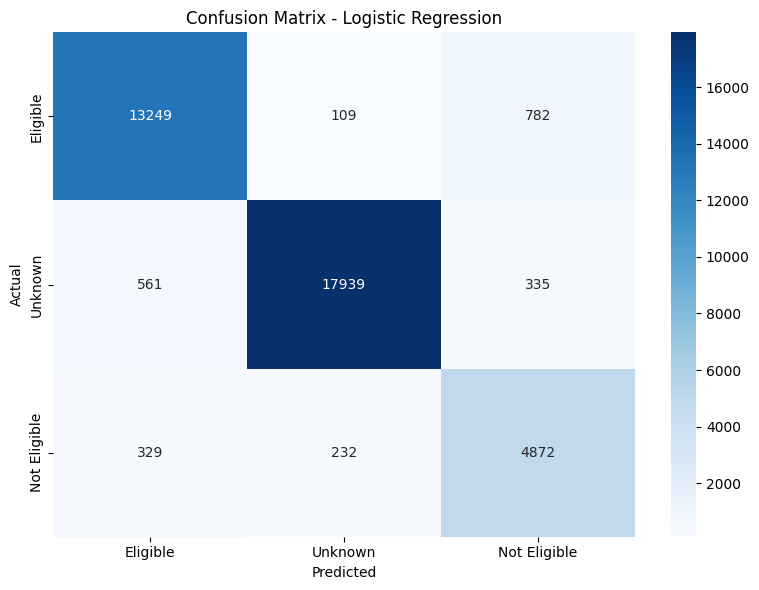

Classification Report:
                                                              precision    recall  f1-score   support

                     Clean Alternative Fuel Vehicle Eligible       0.94      0.94      0.94     14140
Eligibility unknown as battery range has not been researched       0.98      0.95      0.97     18835
                       Not eligible due to low battery range       0.81      0.90      0.85      5433

                                                    accuracy                           0.94     38408
                                                   macro avg       0.91      0.93      0.92     38408
                                                weighted avg       0.94      0.94      0.94     38408



In [ ]:
X_train, X_train_encoded, y_train, X_test_encoded, y_test = prepare_data(df)

best_lr = LogisticRegression(
    C=1,
    penalty='l1',
    solver='saga',
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

best_lr.fit(X_train_encoded, y_train)

# Predict on the test set
y_pred_lr = best_lr.predict(X_test_encoded)
y_score_lr = best_lr.predict_proba(X_test_encoded)


evaluate_model('Logistic Regression', y_test, y_pred_lr)

In [ ]:

# Define groups based on Make, Model, and Model Year
groups = X_train['Make'].astype(str) + '_' + X_train['Model'].astype(str) + '_' + X_train['Model Year'].astype(str)

# Create GroupKFold object
gkf = GroupKFold(n_splits=5)

# Evaluate using GroupKFold with accuracy scoring
lr_cv_scores = cross_val_score(best_lr, X_train_encoded, y_train,
                            cv=gkf.split(X_train_encoded, y_train, groups),
                            scoring='accuracy')

# Output the results
print(f'GroupKFold Accuracy Scores (Logistic Regression): {lr_cv_scores}')
print(f'Mean GroupKFold Accuracy: {lr_cv_scores.mean()}')


/Users/shonie/.pyenv/versions/3.13.1/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/shonie/.pyenv/versions/3.13.1/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/shonie/.pyenv/versions/3.13.1/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/shonie/.pyenv/versions/3.13.1/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


GroupKFold Accuracy Scores (Logistic Regression): [0.9270034  0.89158494 0.88386097 0.95812795 0.95266528]
Mean GroupKFold Accuracy: 0.9226485085624269


/Users/shonie/.pyenv/versions/3.13.1/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


### Support Vector Classifier
Find best hyperparameters  
Train model on most optimum found hyperparameters  
Display the confusion matrix, classification report  
Perform GroupK Fold cross validation

In [ ]:
#SVC Hyperparameter testing

svc = SVC(probability=True, random_state=42)

param_dist = {
    'C': uniform(0.1, 10),
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto'],
    'degree': [2, 3, 4],
    'class_weight': [None, 'balanced']
}

random_search = RandomizedSearchCV(
    estimator=svc,
    param_distributions=param_dist,
    n_iter=30,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2,
    random_state=42
)

random_search.fit(X_train_encoded, y_train)

best_svm = random_search.best_estimator_
best_params = random_search.best_params_

print("Best Hyperparameters (SVM - RandomizedSearchCV):", best_params)


Fitting 5 folds for each of 30 candidates, totalling 150 fits


/Users/shonie/.pyenv/versions/3.13.1/lib/python3.13/site-packages/joblib/externals/loky/backend/fork_exec.py:38: DeprecationWarning: This process (pid=75180) is multi-threaded, use of fork() may lead to deadlocks in the child.
  pid = os.fork()
/Users/shonie/.pyenv/versions/3.13.1/lib/python3.13/site-packages/joblib/externals/loky/backend/fork_exec.py:38: DeprecationWarning: This process (pid=75180) is multi-threaded, use of fork() may lead to deadlocks in the child.
  pid = os.fork()
/Users/shonie/.pyenv/versions/3.13.1/lib/python3.13/site-packages/joblib/externals/loky/backend/fork_exec.py:38: DeprecationWarning: This process (pid=75180) is multi-threaded, use of fork() may lead to deadlocks in the child.
  pid = os.fork()
/Users/shonie/.pyenv/versions/3.13.1/lib/python3.13/site-packages/joblib/externals/loky/backend/fork_exec.py:38: DeprecationWarning: This process (pid=75180) is multi-threaded, use of fork() may lead to deadlocks in the child.
  pid = os.fork()
/Users/shonie/.pyenv

[CV] END C=6.068501579464869, class_weight=balanced, degree=4, gamma=scale, kernel=poly; total time= 9.7min
[CV] END C=6.068501579464869, class_weight=balanced, degree=4, gamma=scale, kernel=poly; total time= 9.9min
[CV] END C=6.068501579464869, class_weight=balanced, degree=4, gamma=scale, kernel=poly; total time=10.0min
[CV] END C=6.068501579464869, class_weight=balanced, degree=4, gamma=scale, kernel=poly; total time=10.0min
[CV] END C=6.068501579464869, class_weight=balanced, degree=4, gamma=scale, kernel=poly; total time=10.0min
[CV] END C=4.692488919658671, class_weight=None, degree=4, gamma=auto, kernel=linear; total time=84.8min
[CV] END C=3.845401188473625, class_weight=None, degree=4, gamma=scale, kernel=linear; total time=96.5min
[CV] END C=3.845401188473625, class_weight=None, degree=4, gamma=scale, kernel=linear; total time=100.0min
[CV] END C=4.692488919658671, class_weight=None, degree=4, gamma=auto, kernel=linear; total time=103.6min
[CV] END C=4.692488919658671, class_


Model: Support Vector Machine (Tuned)
Accuracy: 0.9532


/var/folders/lj/7bdznky91854yv4wc8x1pt8m0000gp/T/ipykernel_75180/1332129848.py:25: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  y_test_named = y_test.replace(label_map)


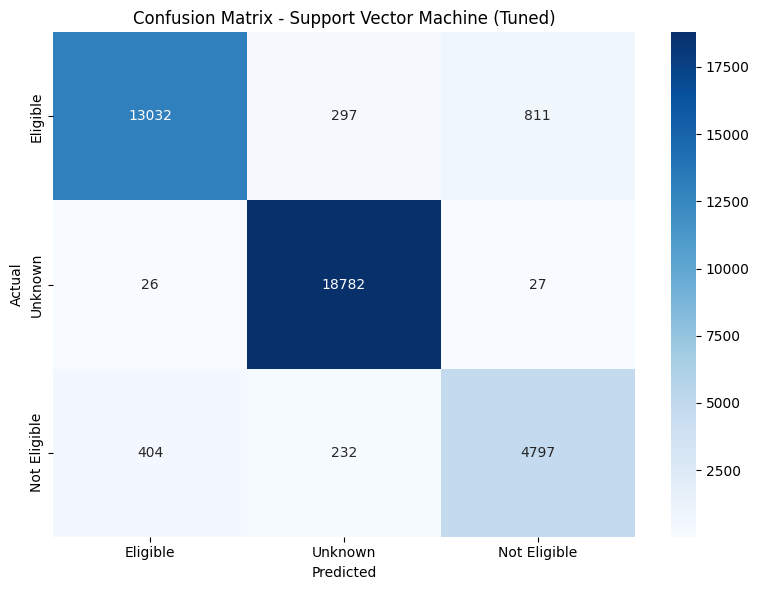

Classification Report:
                                                              precision    recall  f1-score   support

                     Clean Alternative Fuel Vehicle Eligible       0.97      0.92      0.94     14140
Eligibility unknown as battery range has not been researched       0.97      1.00      0.98     18835
                       Not eligible due to low battery range       0.85      0.88      0.87      5433

                                                    accuracy                           0.95     38408
                                                   macro avg       0.93      0.93      0.93     38408
                                                weighted avg       0.95      0.95      0.95     38408



In [ ]:
from sklearn.svm import SVC

X_train, X_train_encoded, y_train, X_test_encoded, y_test = prepare_data(df)

# Best hyperparameters from RandomizedSearchCV
best_params = {
    'C': 8.18397348116461,
    'class_weight': None,
    'degree': 3,
    'gamma': 'scale',
    'kernel': 'rbf',
    'probability': True,
    'random_state': 42
}

# Create and fit the SVM model with best parameters
best_svc = SVC(**best_params)
best_svc.fit(X_train_encoded, y_train)

# Predict on the test set
y_pred_svc = best_svc.predict(X_test_encoded)
y_score_svc = best_svc.predict_proba(X_test_encoded)

# Evaluate the model
evaluate_model('Support Vector Machine (Tuned)', y_test, y_pred_svc)


In [ ]:

# Define group labels
groups = X_train['Make'].astype(str) + '_' + X_train['Model'].astype(str) + '_' + X_train['Model Year'].astype(str)

# Set up GroupKFold
gkf = GroupKFold(n_splits=5)

# Run cross-validation
svm_cv_scores = cross_val_score(svc, X_train_encoded, y_train, cv=gkf, groups=groups, scoring='accuracy')

# Print results
print(f"Group K-Fold CV Accuracy Scores: {svm_cv_scores}")
print(f"Mean Accuracy: {svm_cv_scores.mean():.4f}")


Group K-Fold CV Accuracy Scores: [0.93409218 0.95584125 0.94903196 0.96623304 0.95203008]
Mean Accuracy: 0.9514


### Plot groupk fold cross validation accuracy for all models

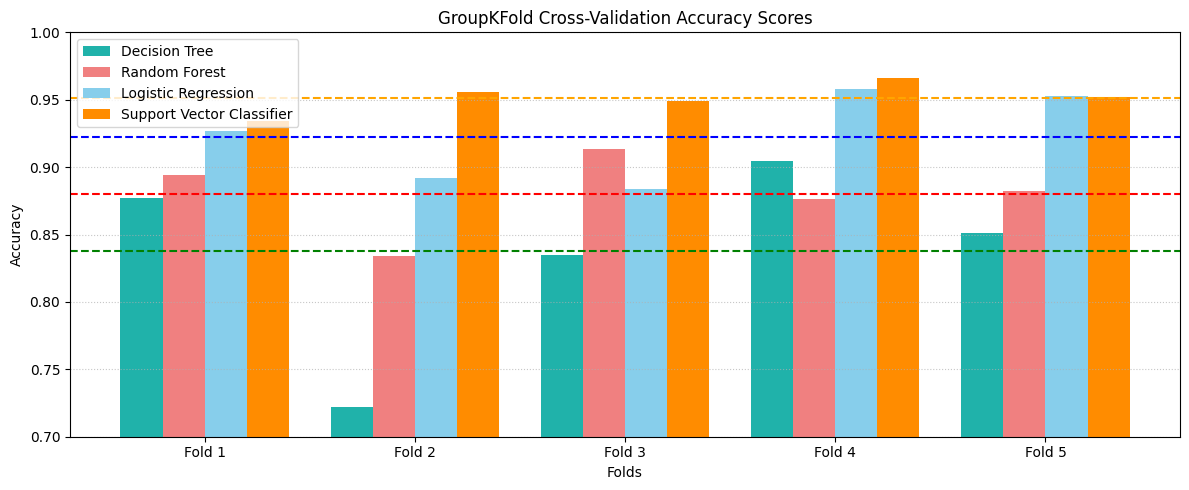

In [ ]:
folds = [f'Fold {i+1}' for i in range(5)]
x = np.arange(len(folds))
width = 0.2

scores = [dt_cv_scores, rf_cv_scores, lr_cv_scores, svm_cv_scores]
labels = ['Decision Tree', 'Random Forest', 'Logistic Regression', 'Support Vector Classifier']
colors = ['lightseagreen', 'lightcoral', 'skyblue', 'darkorange']
mean_colors = ['green', 'red', 'blue', 'orange']

# Create the plot
plt.figure(figsize=(12, 5))

# Dynamically plot each model
for i, (score, label, color) in enumerate(zip(scores, labels, colors)):
    offset = (i - 1.5) * width
    plt.bar(x + offset, score, width=width, label=label, color=color)

# Add mean lines with dynamic labeling
for i, (score, label, color) in enumerate(zip(scores, labels, mean_colors)):
    plt.axhline(y=np.mean(score), color=color, linestyle='--')

plt.ylabel('Accuracy')
plt.xlabel('Folds')
plt.title('GroupKFold Cross-Validation Accuracy Scores')
plt.xticks(x, folds)
plt.ylim(0.70, 1.0)
plt.legend()
plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()


In [ ]:
result_df.head()

,Make,Model,Model Year,Actual CAFV Value,Prediction
0,TESLA,MODEL 3,2019,Eligibility unknown as battery range has not been researched,Eligibility unknown as battery range has not been researched
1,TESLA,MODEL Y,2020,Clean Alternative Fuel Vehicle Eligible,Clean Alternative Fuel Vehicle Eligible
2,HYUNDAI,IONIQ 5,2023,Clean Alternative Fuel Vehicle Eligible,Clean Alternative Fuel Vehicle Eligible
3,BMW,X5,2021,Clean Alternative Fuel Vehicle Eligible,Clean Alternative Fuel Vehicle Eligible
4,TOYOTA,RAV4 PRIME,2023,Not eligible due to low battery range,Not eligible due to low battery range


### Plot Multi class ROC AUC curve

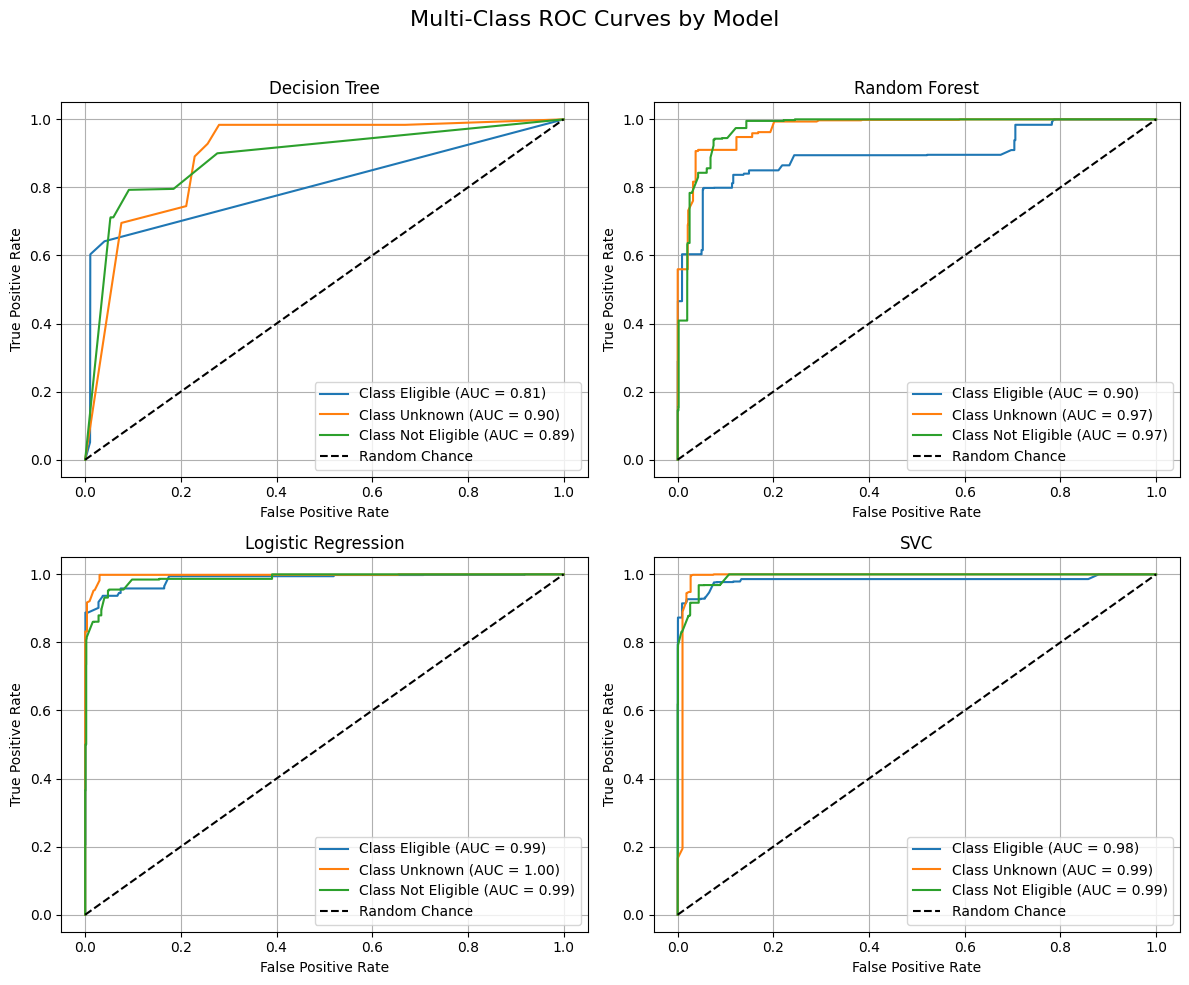

In [ ]:
label_map = {
    'Clean Alternative Fuel Vehicle Eligible': 'Eligible',
    'Eligibility unknown as battery range has not been researched': 'Unknown',
    'Not eligible due to low battery range': 'Not Eligible'
}

original_classes = np.unique(y_test)

mapped_classes = [label_map[c] for c in original_classes]

y_test_bin = label_binarize(y_test, classes=original_classes)
n_classes = len(original_classes)

# Store model names and scores
models = {
    'Decision Tree': y_score_dt,
    'Random Forest': y_score_rf,
    'Logistic Regression': y_score_lr,
    'SVC': y_score_svc
}

# Plot setup: 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for idx, (name, y_score) in enumerate(models.items()):
    ax = axes[idx]

    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, label=f'Class {mapped_classes[i]} (AUC = {roc_auc:.2f})')

    ax.plot([0, 1], [0, 1], 'k--', label='Random Chance')
    ax.set_title(f'{name}')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(loc='lower right')
    ax.grid(True)

plt.suptitle('Multi-Class ROC Curves by Model', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


### Regression

Linear Regression  
Lasso and Ridge Regression  
XGBoost Regressor  
Neural Network  

In [ ]:
#Prepare the data
def prepare_data_regression(df):

    df['combo'] = (
    df['Make'].astype(str) + '_' +
    df['Model'].astype(str) + '_' +
    df['Model Year'].astype(str) + '_' +
    df['County'].astype(str)
    )

    unique_combos = df['combo'].unique()
    train_combos, test_combos = train_test_split(unique_combos, test_size=0.2, random_state=42)

    # Split rows based on those combos
    df_train = df[df['combo'].isin(train_combos)].copy()
    df_test = df[df['combo'].isin(test_combos)].copy()

    # Encode categorical variables (e.g., Make, Model, County)
    df_train_encoded = pd.get_dummies(df_train[['Make', 'Model', 'Model Year', 'County']], drop_first=True)
    df_test_encoded = pd.get_dummies(df_test[['Make', 'Model', 'Model Year', 'County']], drop_first=True)

    df_train_encoded, df_test_encoded = df_train_encoded.align(df_test_encoded, join='left', axis=1, fill_value=0)

    # Add numerical features like Electric Range, Base MSRP.
    df_train_encoded['Electric Range'] = df_train['Electric Range']
    df_train_encoded['Base MSRP'] = df_train['Base MSRP']

    df_test_encoded['Electric Range'] = df_test['Electric Range']
    df_test_encoded['Base MSRP'] = df_test['Base MSRP']

    # Standardize the 'Electric Range' and 'Base MSRP' columns
    scaler = StandardScaler()
    df_train_encoded[['Electric Range', 'Base MSRP']] = scaler.fit_transform(df_train_encoded[['Electric Range', 'Base MSRP']])
    df_test_encoded[['Electric Range', 'Base MSRP']] = scaler.transform(df_test_encoded[['Electric Range', 'Base MSRP']])


    X_train = df_train_encoded
    y_train = df_train['Popularity Percentage']

    X_test = df_test_encoded
    y_test = df_test['Popularity Percentage']


    return X_train, X_test, y_train, y_test, df_test


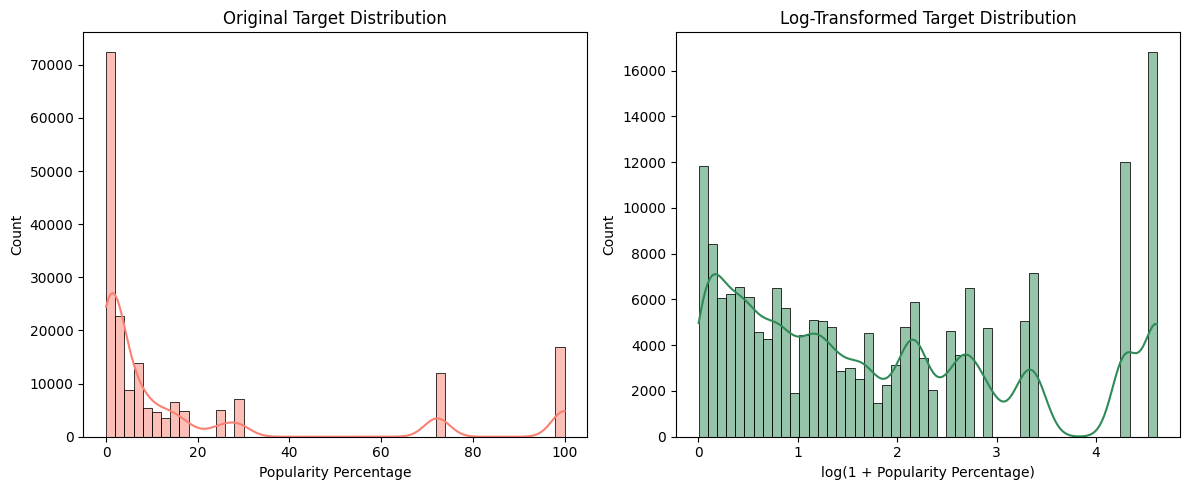

In [ ]:

# Plot original target distribution
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(y_train, kde=True, bins=50, color='salmon')
plt.title('Original Target Distribution')
plt.xlabel('Popularity Percentage')

# Plot log-transformed target distribution
plt.subplot(1, 2, 2)
sns.histplot(np.log1p(y_train), kde=True, bins=50, color='seagreen')
plt.title('Log-Transformed Target Distribution')
plt.xlabel('log(1 + Popularity Percentage)')

plt.tight_layout()
plt.show()


### Linear Models
Linear Regression  
Lasso and Ridge Regression

In [ ]:
X_train, X_test, y_train, y_test, df_test = prepare_data_regression(df)

y_train_log = np.log1p(y_train)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define models
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.01)
}

# Train, predict, and evaluate
for name, model in models.items():
    model.fit(X_train_scaled, y_train_log)
    y_pred_log = model.predict(X_test_scaled)
    y_pred = np.expm1(y_pred_log)


    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print(f"{name}")
    print(f"  MSE:  {mse:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  R²:   {r2:.4f}")
    print("-" * 40)


Linear Regression
  MSE:  362.7964
  RMSE: 19.0472
  R²:   0.7808
----------------------------------------
Ridge Regression
  MSE:  362.8153
  RMSE: 19.0477
  R²:   0.7808
----------------------------------------
Lasso Regression
  MSE:  346.7807
  RMSE: 18.6220
  R²:   0.7904
----------------------------------------


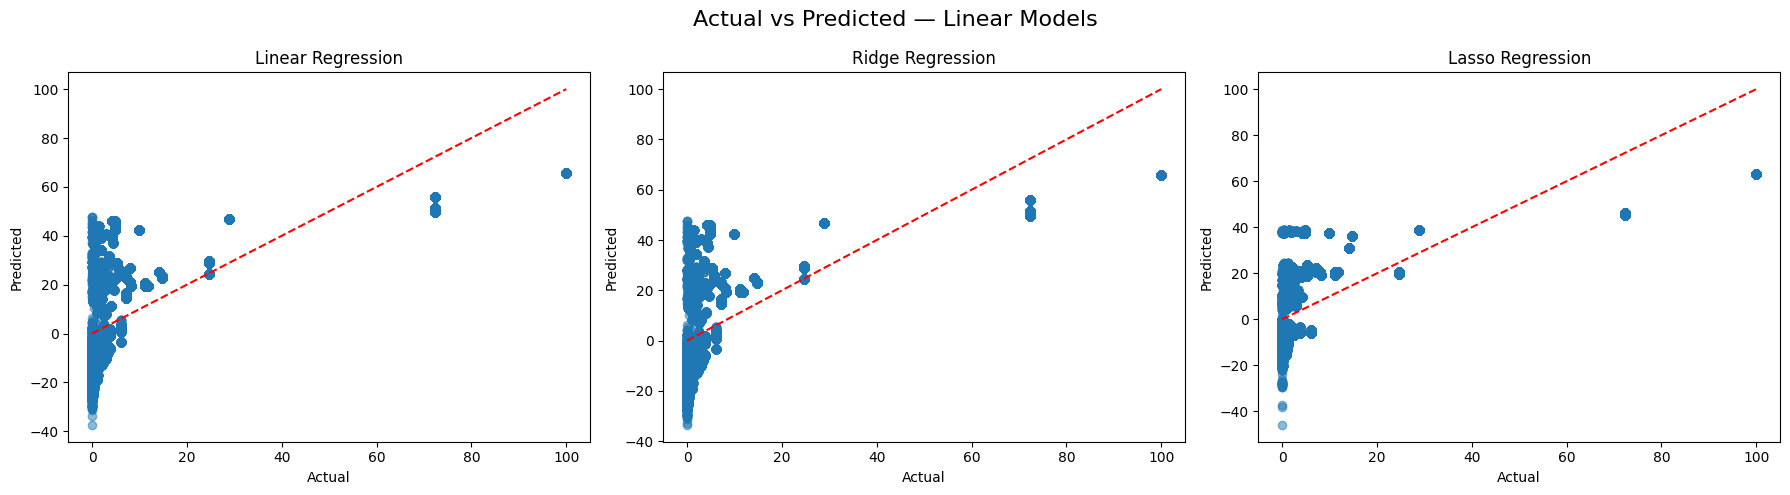

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = {
    'Linear': LinearRegression(),
    'Ridge': Ridge(),
    'Lasso': Lasso()
}

for ax, (name, model) in zip(axes, models.items()):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    ax.scatter(y_test, y_pred, alpha=0.5)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    ax.set_title(f'{name} Regression')
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')

plt.suptitle('Actual vs Predicted — Linear Models', fontsize=16)
plt.tight_layout()
plt.show()


### XGBoost Regressor
Hyperparameter tuning  
Train model on best parameters  
Calculate MSE, RMSE, R squared  
Identify feature importance  
Plot actual vs predicted chart

In [ ]:
#Hyperparameter testing
# XGBoost Regressor
xgb_regressor = xgb.XGBRegressor(random_state=42)

# parameter grid
param_grid = {
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.7, 1.0]
}

# Initialize RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=xgb_regressor,
    param_distributions=param_grid,
    n_iter=100,
    scoring='neg_mean_squared_error',
    cv=3,  # Cross-validation
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# Fit the model to the training data
random_search.fit(X_train, y_train)

# best parameters
best_params = random_search.best_params_

# Best model from the search
best_model = random_search.best_estimator_

print("Best Hyperparameters (XGBoost Regressor - RandomizedSearchCV):", best_params)

Fitting 3 folds for each of 48 candidates, totalling 144 fits


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 48 is smaller than n_iter=100. Running 48 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best Hyperparameters (XGBoost Regressor - RandomizedSearchCV): {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.2, 'colsample_bytree': 1.0}


XGBoost Regressor Mean Squared Error (MSE): 1.0972150579872986
XGBoost Regressor Root Mean Squared Error (RMSE): 1.0474803377568949
XGBoost Regressor R-squared (R2): 0.9993369538775332


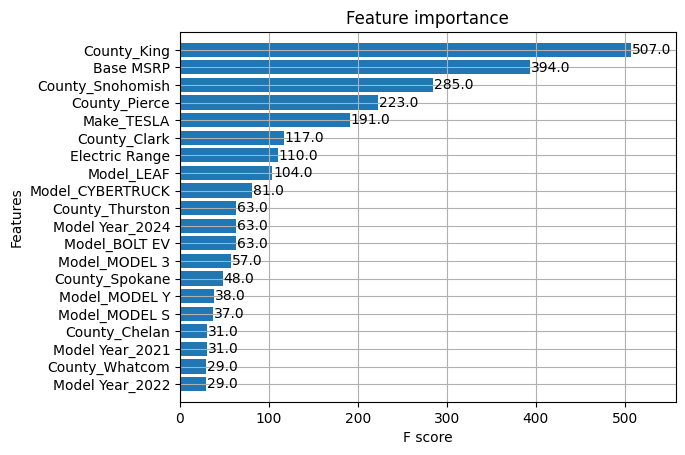

In [ ]:
#XGBoost Regressor train and test

X_train, X_test, y_train, y_test, df_test = prepare_data_regression(df)

y_train_log = np.log1p(y_train)  # log(1 + y)

xgb_regressor = xgb.XGBRegressor(
    subsample=1.0,
    n_estimators=200,
    max_depth=5,
    learning_rate=0.2,
    colsample_bytree=1.0,
    random_state=42
)
#xgb_regressor.fit(X_train, y_train)
xgb_regressor.fit(X_train, y_train_log)

# Predict on test set
y_pred_log = xgb_regressor.predict(X_test)
y_pred_xgb = np.expm1(y_pred_log)

df_test_result = df_test.copy()
df_test_result['Predicted Popularity Percentage'] = y_pred_xgb

# Evaluate XGBoost Regressor Model
mse = mean_squared_error(y_test, y_pred_xgb)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_xgb)

print(f"XGBoost Regressor Mean Squared Error (MSE): {mse}")
print(f"XGBoost Regressor Root Mean Squared Error (RMSE): {rmse}")
print(f"XGBoost Regressor R-squared (R2): {r2}")

# Feature Importance
xgb.plot_importance(xgb_regressor,max_num_features=20, importance_type='weight', height=0.8)
plt.show()


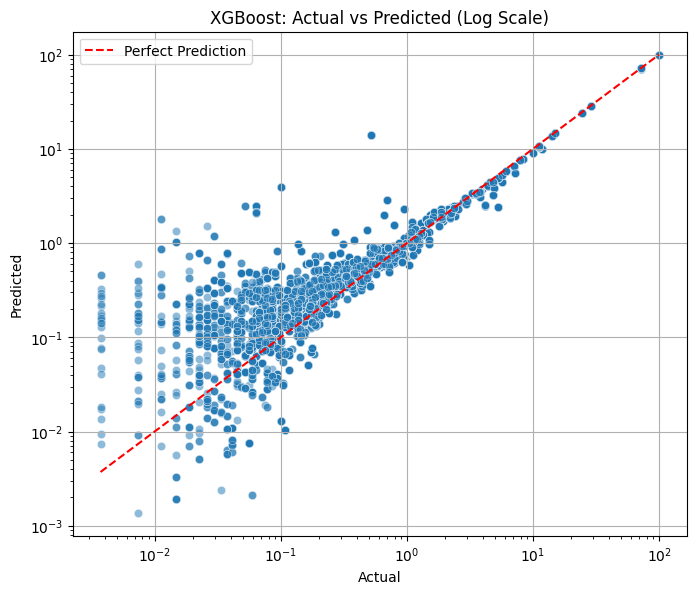

In [ ]:
# Plot chart
plt.figure(figsize=(7, 6))
sns.scatterplot(x=y_test, y=y_pred_xgb, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect Prediction')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('XGBoost: Actual vs Predicted (Log Scale)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.xscale('log')
plt.yscale('log')
plt.show()


In [ ]:
#Print results

#Sort by Predicted Popularity Percentage
top_10_predictions = df_test_result.sort_values(
    by='Predicted Popularity Percentage', ascending=False
).drop_duplicates(subset=['Make', 'Model', 'Model Year', 'County'])

# Limit to top 10
top_10_predictions = top_10_predictions.head(10)

#Select desired columns
top_10_summary = top_10_predictions[[
    'Make-Model', 'Model Year',
    'County', 'Popularity Percentage', 'Predicted Popularity Percentage'
]]

#Combine Make and Model into one column for display
top_10_summary = top_10_summary[[
    'Make-Model', 'Model Year',
    'County', 'Popularity Percentage', 'Predicted Popularity Percentage'
]]

# Display the result
top_10_summary


,Make-Model,Model Year,County,Popularity Percentage,Predicted Popularity Percentage
235686,TESLA MODEL Y,2023,King,100.000000,99.939323
72157,TESLA MODEL 3,2019,King,72.233789,71.375374
223852,TESLA MODEL 3,2021,King,72.233789,71.375374
76364,TESLA MODEL 3,2018,King,72.233789,70.225677
49047,TESLA MODEL Y,2025,Snohomish,28.796104,28.283323
100640,NISSAN LEAF,2016,King,24.564991,24.189911
41930,NISSAN LEAF,2017,King,24.564991,24.189911
144044,NISSAN LEAF,2023,King,24.564991,24.189911
213478,NISSAN LEAF,2012,King,24.564991,23.789759
70081,TESLA MODEL S,2015,King,14.831202,14.641181


### Neural Network

**Architecture:** A simple feedforward neural network with:
1 hidden layer containing 32 neurons  

**ReLU activation** in the hidden layer for introducing non-linearity and handling vanishing gradients  
Linear activation in the output layer, appropriate for regression tasks

**Optimizer:**
**Adam** optimizer was used, known for combining the benefits of momentum and adaptive learning rates for faster and more reliable convergence.  

**Learning Rate:**  
A low learning rate (0.0005) was chosen to allow the model to learn gradually and avoid overshooting the optimal solution.  
Loss Function:  
Mean Squared Error (MSE) was used as the loss function, which is standard for regression problems.  

**Regularization:**.
Early stopping was applied to halt training when validation loss stopped improving, helping prevent overfitting.  

**Batch Size (32):** The model was trained using a mini-batch size of 32, which provides a good balance between training speed and gradient stability. It allows for efficient use of computational resources while maintaining decent generalization.  


**Epochs (50):** The maximum number of training iterations was set to 50 epochs, giving the model enough time to learn without overfitting, and the training stopped after 32 epochs.  


**Early Stopping Patience (5):** The training process used early stopping with a patience of 5, meaning training would stop if the validation loss didn't improve for 5 consecutive epochs. This helps prevent overfitting and ensures the model retains its best weights.



In [24]:
X_train, X_test, y_train, y_test, df_test = prepare_data_regression(df)

model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(1, activation='linear')
])

model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='mse',
    metrics=['mae']
)

#Early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train_log,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

print(f"EarlyStopping triggered: {'Yes' if early_stop.stopped_epoch > 0 else 'No'}")
if early_stop.stopped_epoch > 0:
    print(f" Stopped at epoch: {early_stop.stopped_epoch + 1}")


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
4598/4598 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - loss: 0.6968 - mae: 0.4361 - val_loss: 0.0101 - val_mae: 0.0526
Epoch 2/50
4598/4598 ━━━━━━━━━━━━━━━━━━━━ 21s 3ms/step - loss: 0.0032 - mae: 0.0270 - val_loss: 0.0023 - val_mae: 0.0208
Epoch 3/50
4598/4598 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - loss: 0.0010 - mae: 0.0143 - val_loss: 0.0012 - val_mae: 0.0155
Epoch 4/50
4598/4598 ━━━━━━━━━━━━━━━━━━━━ 22s 3ms/step - loss: 6.0641e-04 - mae: 0.0110 - val_loss: 8.1548e-04 - val_mae: 0.0114
Epoch 5/50
4598/4598 ━━━━━━━━━━━━━━━━━━━━ 25s 4ms/step - loss: 3.6901e-04 - mae: 0.0093 - val_loss: 5.1899e-04 - val_mae: 0.0101
Epoch 6/50
4598/4598 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step - loss: 2.4526e-04 - mae: 0.0084 - val_loss: 4.1862e-04 - val_mae: 0.0083
Epoch 7/50
4598/4598 ━━━━━━━━━━━━━━━━━━━━ 22s 3ms/step - loss: 2.1746e-04 - mae: 0.0081 - val_loss: 3.5652e-04 - val_mae: 0.0086
Epoch 8/50
4598/4598 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - loss: 1.7135e-04 - mae: 0.0076 - val_loss: 2.5019e-04 - val_mae:

In [25]:

y_pred_log_nn = model.predict(X_test).flatten()
y_pred_nn = np.expm1(y_pred_log_nn)

mse_nn = mean_squared_error(y_test, y_pred_nn)
rmse_nn = np.sqrt(mse_nn)
r2_nn = r2_score(y_test, y_pred_nn)

print(f"Neural Net MSE: {mse_nn:.4f}")
print(f"Neural Net RMSE: {rmse_nn:.4f}")
print(f"Neural Net R²: {r2_nn:.4f}")


1603/1603 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
Neural Net MSE: 0.0180
Neural Net RMSE: 0.1343
Neural Net R²: 1.0000


1603/1603 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


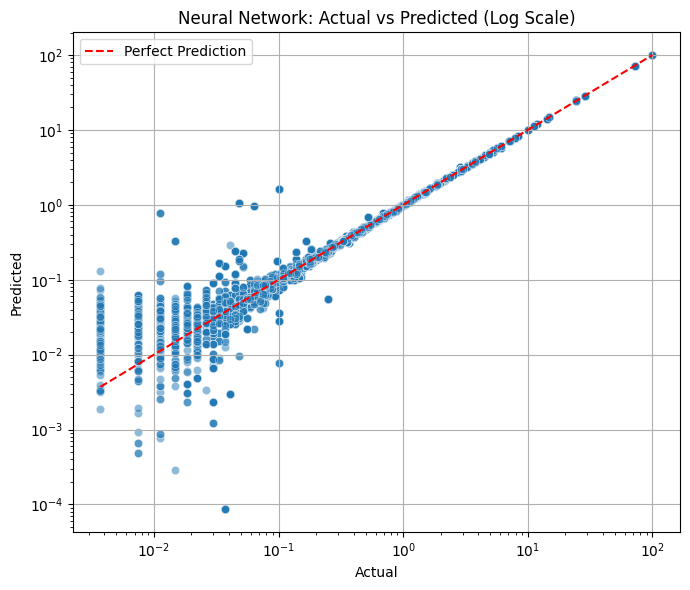

In [ ]:
# Predict (log) and inverse transform back to original scale
y_pred_nn_log = model.predict(X_test).flatten()
y_pred_nn = np.expm1(y_pred_nn_log)  # Inverse of log1p

# Plot: Actual vs Predicted
plt.figure(figsize=(7, 6))
sns.scatterplot(x=y_test, y=y_pred_nn, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect Prediction')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Neural Network: Actual vs Predicted (Log Scale)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
